<a href="https://colab.research.google.com/github/JPAmewu/My_Capstone_1_Imperial/blob/main/Week_11/02_Notebook/Week_11_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11 Capstone — Bayesian Optimisation

This notebook appends the confirmed Week 10 observations to the Week 10 dataset, creating the Week 11 dataset before EDA and GP/UCB query selection.


For each function for Week_10, I will follow this sequence:
1. Create week_11_dataset
2. Extract function
3. Check shapes and missing values
4. Calculate summary statistics
5. Plot the output trend
6. Plot the best-so-far trend
7. Identify the best query point
8. Plot the correlation heatmap
9. Plot each input against the output
10. Fit a Gaussian Process surrogate
11. Apply UCB to generate the next query point

In [1]:
# 1. Unzip the Week 10 dataset

import os
import shutil
import zipfile

import numpy as np

zip_path = "/content/week_10_dataset.zip"
extract_path = "/content/week_10_dataset"

# Remove an old extracted copy, if present.
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Week 10 dataset extracted successfully.")


Week 10 dataset extracted successfully.


In [2]:
# 2. Check the extracted .npy files

for root, folders, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".npy"):
            print(os.path.join(root, file))

/content/week_10_dataset/week_10_dataset/function_6_inputs.npy
/content/week_10_dataset/week_10_dataset/function_4_inputs.npy
/content/week_10_dataset/week_10_dataset/function_7_outputs.npy
/content/week_10_dataset/week_10_dataset/function_3_inputs.npy
/content/week_10_dataset/week_10_dataset/function_7_inputs.npy
/content/week_10_dataset/week_10_dataset/function_1_outputs.npy
/content/week_10_dataset/week_10_dataset/function_3_outputs.npy
/content/week_10_dataset/week_10_dataset/function_5_outputs.npy
/content/week_10_dataset/week_10_dataset/function_2_inputs.npy
/content/week_10_dataset/week_10_dataset/function_1_inputs.npy
/content/week_10_dataset/week_10_dataset/function_8_inputs.npy
/content/week_10_dataset/week_10_dataset/function_2_outputs.npy
/content/week_10_dataset/week_10_dataset/function_5_inputs.npy
/content/week_10_dataset/week_10_dataset/function_4_outputs.npy
/content/week_10_dataset/week_10_dataset/function_8_outputs.npy
/content/week_10_dataset/week_10_dataset/functio

In [3]:
# 3. Load and validate the Week 10 dataset

EXPECTED_DIMENSIONS = {
    1: 2,
    2: 2,
    3: 3,
    4: 4,
    5: 4,
    6: 5,
    7: 6,
    8: 8,
}


def find_npy_file(folder, function_number, data_type):
    """Return the unique input or output array for a function."""
    if data_type not in {"input", "output"}:
        raise ValueError("data_type must be 'input' or 'output'.")

    expected_name = f"function_{function_number}_{data_type}s.npy"
    matching_files = sorted(
        os.path.join(root, filename)
        for root, _, files in os.walk(folder)
        for filename in files
        if filename.lower() == expected_name
    )

    if not matching_files:
        raise FileNotFoundError(
            f"No exact {data_type} file found for Function "
            f"{function_number}: {expected_name}"
        )

    if len(matching_files) > 1:
        raise RuntimeError(
            f"Multiple {data_type} files found for Function "
            f"{function_number}: {matching_files}"
        )

    return matching_files[0]


week_10_X = {}
week_10_y = {}

for function_number in range(1, 9):
    input_file = find_npy_file(
        extract_path,
        function_number,
        "input",
    )
    output_file = find_npy_file(
        extract_path,
        function_number,
        "output",
    )

    expected_dimension = EXPECTED_DIMENSIONS[function_number]
    inputs = np.asarray(np.load(input_file), dtype=float)
    outputs = np.asarray(np.load(output_file), dtype=float).reshape(-1, 1)

    if inputs.ndim == 1:
        if inputs.size % expected_dimension:
            raise ValueError(
                f"Function {function_number}: {inputs.size} input values "
                f"cannot be reshaped to dimension {expected_dimension}."
            )
        inputs = inputs.reshape(-1, expected_dimension)

    if inputs.ndim != 2 or inputs.shape[1] != expected_dimension:
        raise ValueError(
            f"Function {function_number}: expected a two-dimensional input "
            f"array with {expected_dimension} columns, got {inputs.shape}."
        )

    if not np.isfinite(inputs).all() or not np.isfinite(outputs).all():
        raise ValueError(
            f"Function {function_number}: input or output contains "
            "non-finite values."
        )

    week_10_X[function_number] = inputs
    week_10_y[function_number] = outputs

    print(f"Function {function_number}")
    print("Input shape :", inputs.shape)
    print("Output shape:", outputs.shape)
    print("-" * 40)


Function 1
Input shape : (19, 2)
Output shape: (19, 1)
----------------------------------------
Function 2
Input shape : (19, 2)
Output shape: (19, 1)
----------------------------------------
Function 3
Input shape : (24, 3)
Output shape: (24, 1)
----------------------------------------
Function 4
Input shape : (39, 4)
Output shape: (39, 1)
----------------------------------------
Function 5
Input shape : (29, 4)
Output shape: (29, 1)
----------------------------------------
Function 6
Input shape : (29, 5)
Output shape: (29, 1)
----------------------------------------
Function 7
Input shape : (39, 6)
Output shape: (39, 1)
----------------------------------------
Function 8
Input shape : (48, 8)
Output shape: (48, 1)
----------------------------------------


In [4]:
# Validate input-output alignment without modifying the raw dataset.

for function_number in range(1, 9):
    input_rows = week_10_X[function_number].shape[0]
    output_rows = week_10_y[function_number].shape[0]

    if input_rows != output_rows:
        raise ValueError(
            f"Function {function_number}: found {input_rows} input rows and "
            f"{output_rows} outputs. Resolve the mismatch against the original "
            "query history before creating the Week 11 dataset."
        )

print("All Week 10 input and output arrays are aligned.")


All Week 10 input and output arrays are aligned.


In [5]:
# Raw Week 10 files remain unchanged.
print("Validation complete; no source dataset files were overwritten.")


Validation complete; no source dataset files were overwritten.


In [6]:
# Confirmed Week 10 query points and returned outputs.
new_X = {key: np.array(value, dtype=float) for key, value in {1: [[0.379403, 0.071186]], 2: [[0.329121, 0.99795]], 3: [[0.447317, 0.65893, 0.324854]], 4: [[0.587928, 0.514452, 0.045793, 0.032616]], 5: [[0.005552, 0.918769, 0.692571, 0.988052]], 6: [[0.853051, 0.152023, 0.700695, 0.554516, 0.611033]], 7: [[0.107447, 0.625529, 0.309529, 0.130105, 0.44366, 0.667717]], 8: [[0.546897, 0.163123, 0.136484, 0.078398, 0.771803, 0.070794, 0.119397, 0.111488]]}.items()}
new_y = {key: np.array(value, dtype=float) for key, value in {1: [[-3.089423814911752e-96]], 2: [[0.049406406222616564]], 3: [[-0.08189344986506433]], 4: [[-23.42280313862202]], 5: [[430.8031249775375]], 6: [[-1.1717131510084098]], 7: [[1.009894033457839]], 8: [[9.6998918101966]]}.items()}

for function_number in range(1, 9):
    print(
        f"Function {function_number}: "
        f"input {new_X[function_number].shape}, "
        f"output {new_y[function_number].shape}"
    )


Function 1: input (1, 2), output (1, 1)
Function 2: input (1, 2), output (1, 1)
Function 3: input (1, 3), output (1, 1)
Function 4: input (1, 4), output (1, 1)
Function 5: input (1, 4), output (1, 1)
Function 6: input (1, 5), output (1, 1)
Function 7: input (1, 6), output (1, 1)
Function 8: input (1, 8), output (1, 1)


In [7]:
week_11_X = {}
week_11_y = {}

for function_number in range(1, 9):
    old_X = week_10_X[function_number]
    old_y = week_10_y[function_number]
    current_X = new_X[function_number]
    current_y = new_y[function_number]

    if old_X.shape[0] != old_y.shape[0]:
        raise ValueError(
            f"Function {function_number}: existing input/output row mismatch."
        )

    if old_X.shape[1] != current_X.shape[1]:
        raise ValueError(
            f"Function {function_number}: input dimension mismatch. "
            f"Existing data has {old_X.shape[1]} columns, "
            f"but the new input has {current_X.shape[1]} columns."
        )

    if current_X.shape[0] != current_y.shape[0]:
        raise ValueError(
            f"Function {function_number}: new input/output row mismatch."
        )

    week_11_X[function_number] = np.vstack([old_X, current_X])
    week_11_y[function_number] = np.vstack([old_y, current_y])

    print(f"Function {function_number}")
    print("Week 10 input shape :", old_X.shape)
    print("Week 10 output shape:", old_y.shape)
    print("Week 11 input shape:", week_11_X[function_number].shape)
    print("Week 11 output shape:", week_11_y[function_number].shape)
    print("-" * 45)


Function 1
Week 10 input shape : (19, 2)
Week 10 output shape: (19, 1)
Week 11 input shape: (20, 2)
Week 11 output shape: (20, 1)
---------------------------------------------
Function 2
Week 10 input shape : (19, 2)
Week 10 output shape: (19, 1)
Week 11 input shape: (20, 2)
Week 11 output shape: (20, 1)
---------------------------------------------
Function 3
Week 10 input shape : (24, 3)
Week 10 output shape: (24, 1)
Week 11 input shape: (25, 3)
Week 11 output shape: (25, 1)
---------------------------------------------
Function 4
Week 10 input shape : (39, 4)
Week 10 output shape: (39, 1)
Week 11 input shape: (40, 4)
Week 11 output shape: (40, 1)
---------------------------------------------
Function 5
Week 10 input shape : (29, 4)
Week 10 output shape: (29, 1)
Week 11 input shape: (30, 4)
Week 11 output shape: (30, 1)
---------------------------------------------
Function 6
Week 10 input shape : (29, 5)
Week 10 output shape: (29, 1)
Week 11 input shape: (30, 5)
Week 11 output shape

In [8]:
from google.colab import drive

drive.mount("/content/drive")

week_11_folder = "/content/drive/MyDrive/week_11_dataset"
os.makedirs(week_11_folder, exist_ok=True)

for function_number in range(1, 9):
    input_file = os.path.join(
        week_11_folder,
        f"function_{function_number}_inputs.npy",
    )
    output_file = os.path.join(
        week_11_folder,
        f"function_{function_number}_outputs.npy",
    )

    np.save(input_file, week_11_X[function_number])
    np.save(output_file, week_11_y[function_number])

print("Week 11 dataset saved successfully.")
print("Folder:", week_11_folder)


Mounted at /content/drive
Week 11 dataset saved successfully.
Folder: /content/drive/MyDrive/week_11_dataset


In [9]:
for function_number in range(1, 9):

    saved_X = np.load(
        os.path.join(
            week_11_folder,
            f"function_{function_number}_inputs.npy"
        )
    )

    saved_y = np.load(
        os.path.join(
            week_11_folder,
            f"function_{function_number}_outputs.npy"
        )
    )

    status = (
        "MATCHED"
        if saved_X.shape[0] == saved_y.shape[0]
        else "NOT MATCHED"
    )

    print(
        f"Function {function_number}: "
        f"input {saved_X.shape}, "
        f"output {saved_y.shape} — {status}"
    )

Function 1: input (20, 2), output (20, 1) — MATCHED
Function 2: input (20, 2), output (20, 1) — MATCHED
Function 3: input (25, 3), output (25, 1) — MATCHED
Function 4: input (40, 4), output (40, 1) — MATCHED
Function 5: input (30, 4), output (30, 1) — MATCHED
Function 6: input (30, 5), output (30, 1) — MATCHED
Function 7: input (40, 6), output (40, 1) — MATCHED
Function 8: input (49, 8), output (49, 1) — MATCHED


In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")




**Function**-by-function EDA function

1. Loading of inputs and outputs
2. Shape checks
3. Missing and infinite-value checks
4. Summary statistics
5. Output trend
6. Best-so-far trend
7. Best observed query point
8. Correlation heatmap
9. Input-output scatter plots
10. Top five observations

In [11]:
def conduct_function_eda(function_number, dataset_folder):
    """
    Conduct exploratory data analysis for one black-box function.

    Parameters
    ----------
    function_number : int
        Function number from 1 to 8.

    dataset_folder : str
        Folder containing the .npy files.
    """

    # ---------------------------------------------------------
    # 1. Build the file paths
    # ---------------------------------------------------------
    input_path = os.path.join(
        dataset_folder,
        f"function_{function_number}_inputs.npy"
    )

    output_path = os.path.join(
        dataset_folder,
        f"function_{function_number}_outputs.npy"
    )

    # ---------------------------------------------------------
    # 2. Check that the files exist
    # ---------------------------------------------------------
    if not os.path.exists(input_path):
        raise FileNotFoundError(
            f"Input file not found: {input_path}"
        )

    if not os.path.exists(output_path):
        raise FileNotFoundError(
            f"Output file not found: {output_path}"
        )

    # ---------------------------------------------------------
    # 3. Load the arrays
    # ---------------------------------------------------------
    X = np.load(input_path)
    y = np.load(output_path)

    # Make sure X is two-dimensional
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    # Convert output from shape (n, 1) into shape (n,)
    y = y.reshape(-1)

    # ---------------------------------------------------------
    # 4. Check input-output matching
    # ---------------------------------------------------------
    if X.shape[0] != y.shape[0]:
        raise ValueError(
            f"Function {function_number} is not matched: "
            f"{X.shape[0]} input rows and {y.shape[0]} outputs."
        )

    # ---------------------------------------------------------
    # 5. Create a DataFrame
    # ---------------------------------------------------------
    input_columns = [
        f"x{i + 1}" for i in range(X.shape[1])
    ]

    df = pd.DataFrame(
        X,
        columns=input_columns
    )

    df["output"] = y

    # ---------------------------------------------------------
    # 6. Basic information
    # ---------------------------------------------------------
    print("\n")
    print("=" * 70)
    print(f"FUNCTION {function_number} EDA")
    print("=" * 70)

    print("\nDataset structure")
    print("-" * 40)
    print("Input shape :", X.shape)
    print("Output shape:", y.shape)
    print("Observations:", X.shape[0])
    print("Dimensions  :", X.shape[1])

    print("\nFirst five observations")
    print("-" * 40)
    display(df.head())

    # ---------------------------------------------------------
    # 7. Data-quality checks
    # ---------------------------------------------------------
    missing_values = df.isnull().sum()
    infinite_values = pd.Series(
        np.isinf(df.to_numpy()).sum(axis=0),
        index=df.columns
    )

    duplicate_rows = df.duplicated().sum()

    print("\nMissing values")
    print("-" * 40)
    print(missing_values)

    print("\nInfinite values")
    print("-" * 40)
    print(infinite_values)

    print("\nDuplicate rows")
    print("-" * 40)
    print(duplicate_rows)

    # ---------------------------------------------------------
    # 8. Summary statistics
    # ---------------------------------------------------------
    summary = df.describe().T

    summary["median"] = df.median()
    summary["variance"] = df.var()
    summary["skewness"] = df.skew()

    print("\nSummary statistics")
    print("-" * 40)
    display(summary)

    # ---------------------------------------------------------
    # 9. Find the best observed result
    # Maximisation objective
    # ---------------------------------------------------------
    best_index = int(np.argmax(y))
    best_output = float(y[best_index])
    best_input = X[best_index]

    print("\nBest observed result")
    print("-" * 40)
    print("Best array index       :", best_index)
    print("Best observation number:", best_index + 1)
    print("Best query point       :", best_input)
    print("Best output value      :", best_output)

    # ---------------------------------------------------------
    # 10. Top five observations
    # ---------------------------------------------------------
    top_five = (
        df.sort_values(
            by="output",
            ascending=False
        )
        .head(5)
    )

    print("\nTop five observations")
    print("-" * 40)
    display(top_five)

    # ---------------------------------------------------------
    # 11. Output trend
    # ---------------------------------------------------------
    observation_numbers = np.arange(1, len(y) + 1)

    plt.figure(figsize=(11, 5))

    plt.plot(
        observation_numbers,
        y,
        marker="o"
    )

    plt.scatter(
        best_index + 1,
        best_output,
        marker="*",
        s=250,
        label="Best observed output"
    )

    plt.xlabel("Observation number")
    plt.ylabel("Output")
    plt.title(
        f"Function {function_number}: Output Trend"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 12. Best-so-far trend
    # ---------------------------------------------------------
    best_so_far = np.maximum.accumulate(y)

    plt.figure(figsize=(11, 5))

    plt.plot(
        observation_numbers,
        best_so_far,
        marker="o"
    )

    plt.xlabel("Observation number")
    plt.ylabel("Best output found so far")
    plt.title(
        f"Function {function_number}: Best-So-Far Trend"
    )

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 13. Output distribution
    # ---------------------------------------------------------
    plt.figure(figsize=(9, 5))

    plt.hist(
        y,
        bins= 8,
        edgecolor="black"
    )

    plt.axvline(
        np.mean(y),
        linestyle="--",
        label=f"Mean = {np.mean(y):.5g}"
    )

    plt.axvline(
        np.median(y),
        linestyle=":",
        label=f"Median = {np.median(y):.5g}"
    )

    plt.xlabel("Output")
    plt.ylabel("Frequency")
    plt.title(
        f"Function {function_number}: Output Distribution"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 14. Correlation heatmap
    # ---------------------------------------------------------
    correlation = df.corr(numeric_only=True)

    plt.figure(
        figsize=(
            max(7, X.shape[1] + 3),
            max(5, X.shape[1] + 2)
        )
    )

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title(
        f"Function {function_number}: Correlation Heatmap"
    )

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 15. Each input against the output
    # ---------------------------------------------------------
    for column in input_columns:

        plt.figure(figsize=(8, 5))

        plt.scatter(
            df[column],
            df["output"],
            alpha=0.75
        )

        plt.scatter(
            df.loc[best_index, column],
            df.loc[best_index, "output"],
            marker="*",
            s=250,
            label="Best observed point"
        )

        plt.xlabel(column)
        plt.ylabel("Output")

        plt.title(
            f"Function {function_number}: "
            f"{column} Against Output"
        )

        plt.legend()
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------
    # 16. Input-output correlations
    # ---------------------------------------------------------
    output_correlations = (
        correlation["output"]
        .drop("output")
        .sort_values(
            key=lambda values: values.abs(),
            ascending=False
        )
    )

    print("\nInput-output correlations")
    print("-" * 40)
    print(output_correlations)

    # ---------------------------------------------------------
    # 17. Concise report
    # ---------------------------------------------------------
    print("\nConcise EDA report")
    print("-" * 40)

    print(f"Observations       : {X.shape[0]}")
    print(f"Input dimensions   : {X.shape[1]}")
    print(f"Missing values     : {df.isnull().sum().sum()}")
    print(f"Infinite values    : {np.isinf(df.to_numpy()).sum()}")
    print(f"Duplicate rows     : {duplicate_rows}")
    print(f"Minimum output     : {np.min(y):.10g}")
    print(f"Mean output        : {np.mean(y):.10g}")
    print(f"Median output      : {np.median(y):.10g}")
    print(f"Maximum output     : {np.max(y):.10g}")
    print(f"Best observation   : {best_index + 1}")
    print(f"Best query point   : {best_input}")
    print(f"Best output        : {best_output:.10g}")

    # Return the important objects
    return {
        "function": function_number,
        "X": X,
        "y": y,
        "dataframe": df,
        "summary": summary,
        "correlation": correlation,
        "best_index": best_index,
        "best_input": best_input,
        "best_output": best_output,
        "best_so_far": best_so_far,
        "top_five": top_five
    }



FUNCTION 1 EDA

Dataset structure
----------------------------------------
Input shape : (20, 2)
Output shape: (20,)
Observations: 20
Dimensions  : 2

First five observations
----------------------------------------


,x1,x2,output
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03



Missing values
----------------------------------------
x1        0
x2        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
3

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,20.0,0.515376,0.236390,0.082507,3.745400e-01,3.949201e-01,6.953195e-01,0.897714,3.949201e-01,0.055880,0.414615
x2,20.0,0.615935,0.364504,0.071186,2.354373e-01,7.479796e-01,9.507140e-01,0.999543,7.479796e-01,0.132863,-0.558328
output,20.0,12.799820,26.265138,-0.003606,-7.723560e-97,1.803386e-81,1.927719e-16,64.000000,1.803386e-81,689.857491,1.624466



Best observed result
----------------------------------------
Best array index       : 10
Best observation number: 11
Best query point       : [0.37454  0.950714]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,output
12,0.374540,0.950714,6.400000e+01
13,0.374540,0.950714,6.400000e+01
11,0.374540,0.950714,6.400000e+01
10,0.374540,0.950714,6.400000e+01
2,0.731024,0.733000,7.710875e-16


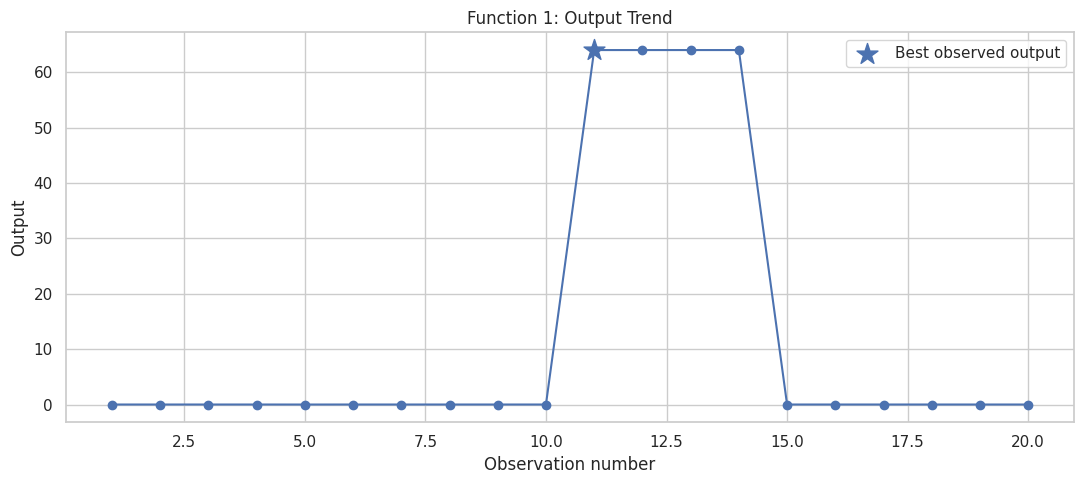

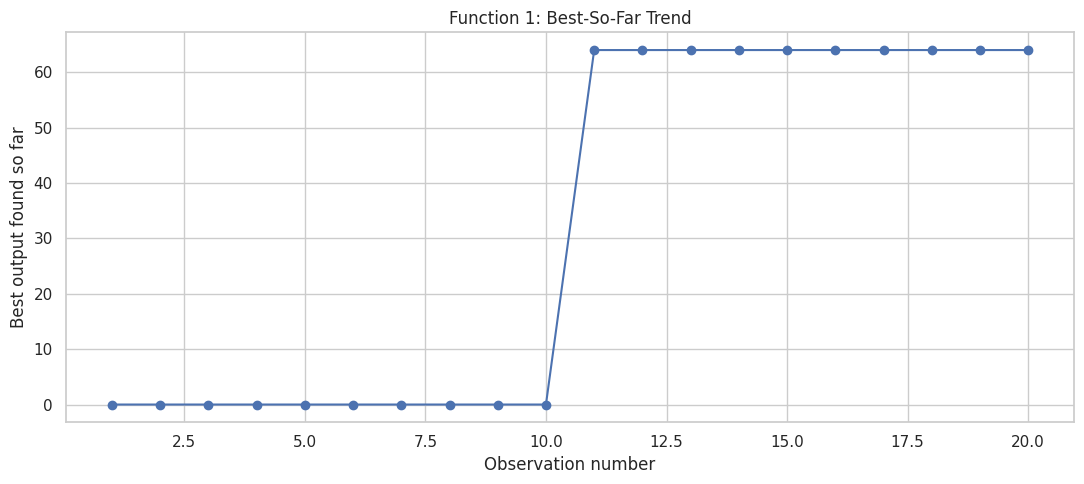

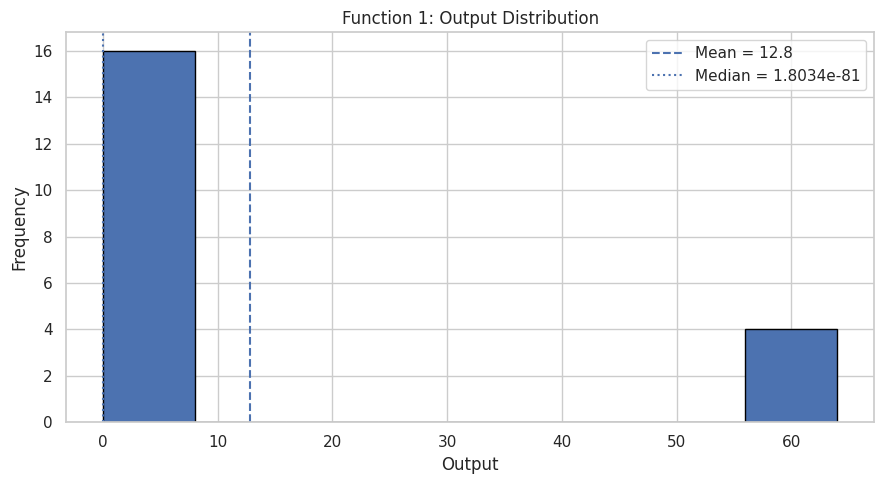

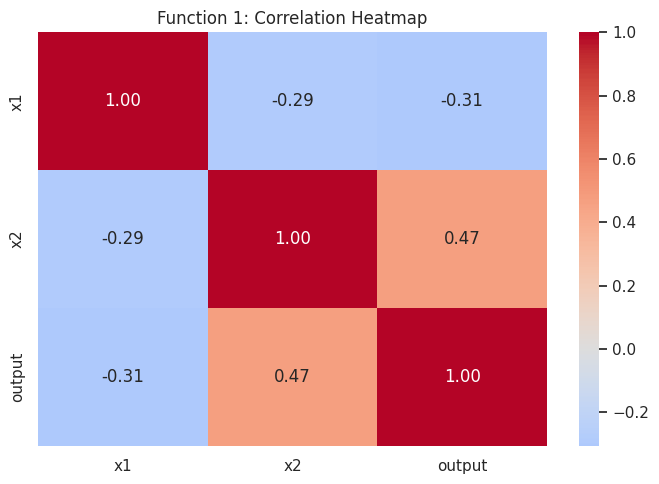

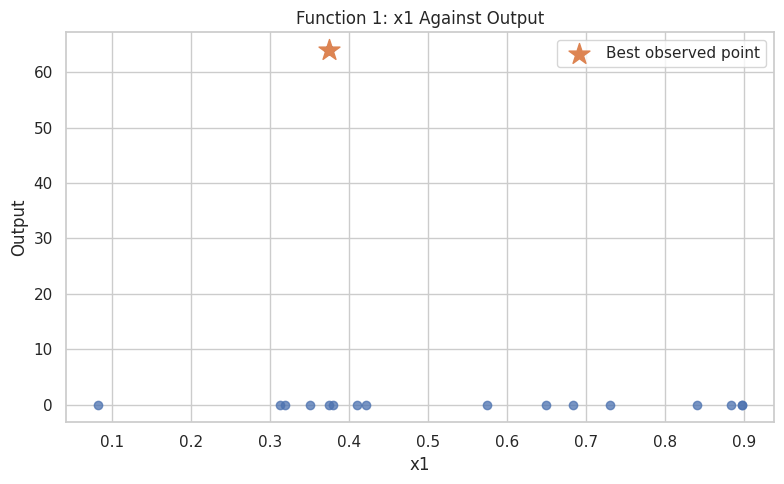

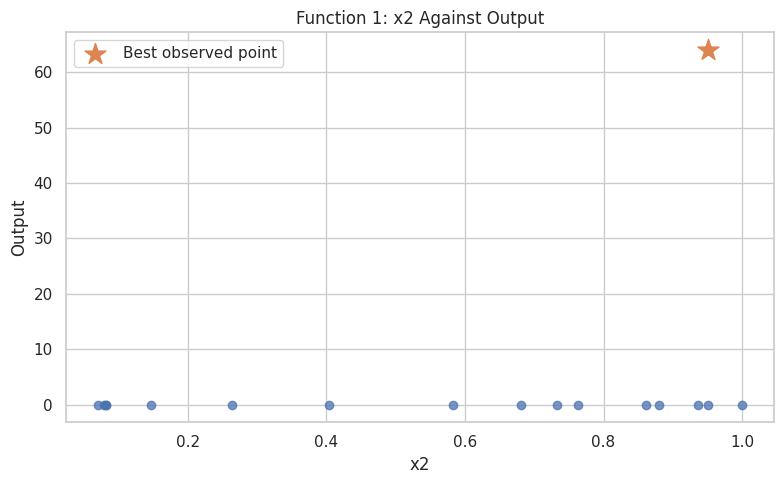


Input-output correlations
----------------------------------------
x2    0.471153
x1   -0.305632
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 20
Input dimensions   : 2
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 3
Minimum output     : -0.003606062644
Mean output        : 12.7998197
Median output      : 1.803385595e-81
Maximum output     : 64
Best observation   : 11
Best query point   : [0.37454  0.950714]
Best output        : 64


In [12]:
# Conduct Function 1 EDA

eda_1 = conduct_function_eda(
    function_number=1,
    dataset_folder=week_11_folder
)



FUNCTION 2 EDA

Dataset structure
----------------------------------------
Input shape : (20, 2)
Output shape: (20,)
Observations: 20
Dimensions  : 2

First five observations
----------------------------------------


,x1,x2,output
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965



Missing values
----------------------------------------
x1        0
x2        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
3

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,20.0,0.485133,0.242418,0.009675,3.663424e-01,0.406353,0.599735,0.995366,0.406353,0.058766,0.383150
x2,20.0,0.622765,0.350421,0.028698,3.343676e-01,0.741547,0.950714,0.999881,0.741547,0.122795,-0.430805
output,20.0,3.343200,14.278445,-0.065624,-1.560647e-117,0.049406,0.256963,64.000000,0.049406,203.874003,4.470765



Best observed result
----------------------------------------
Best array index       : 13
Best observation number: 14
Best query point       : [0.37454  0.950714]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,output
13,0.374540,0.950714,64.000000
9,0.702637,0.926564,0.611205
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
3,0.845275,0.711120,0.293993


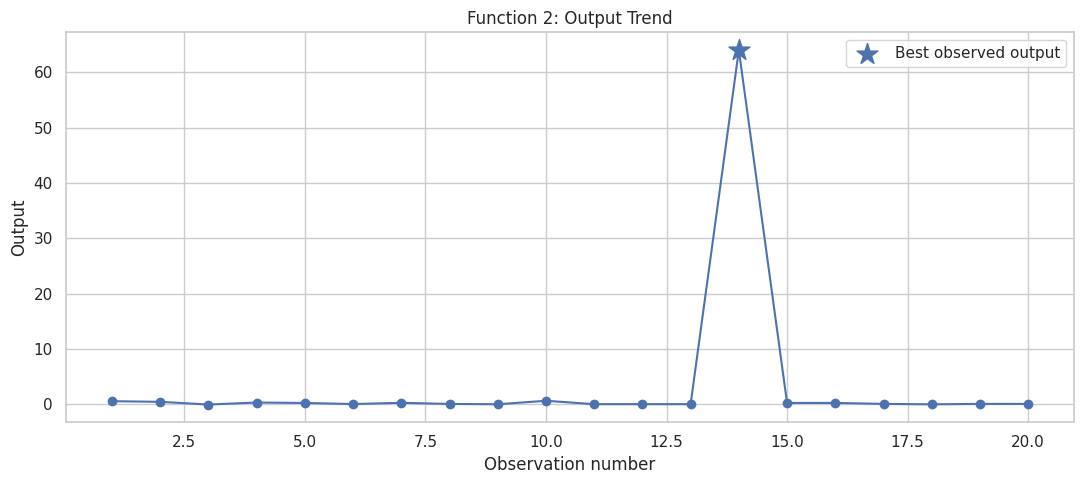

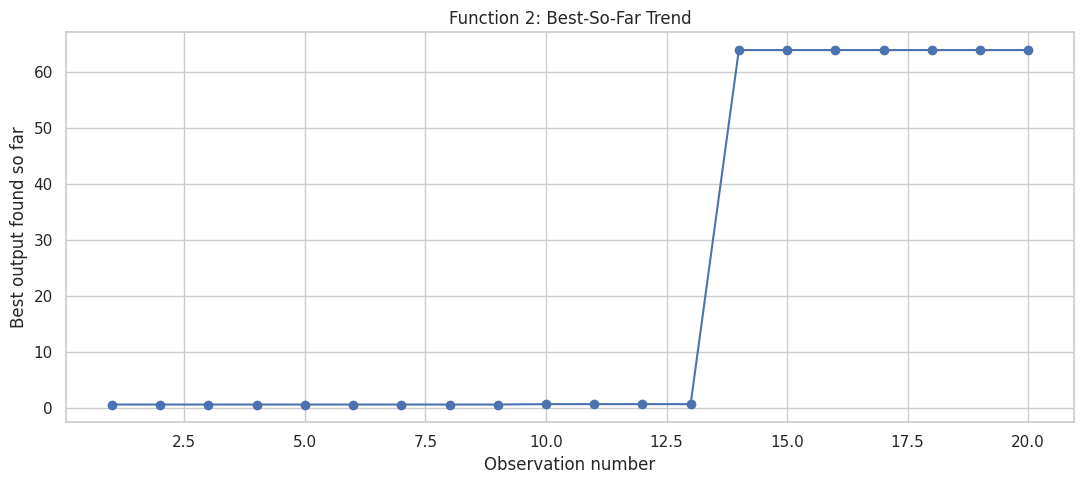

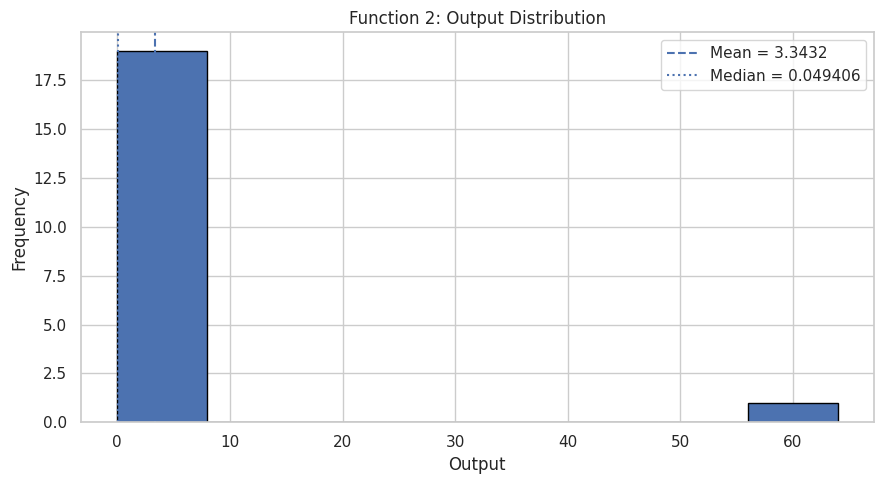

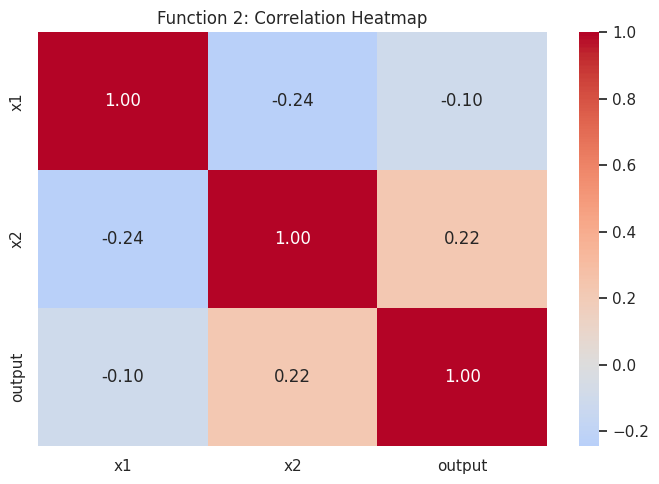

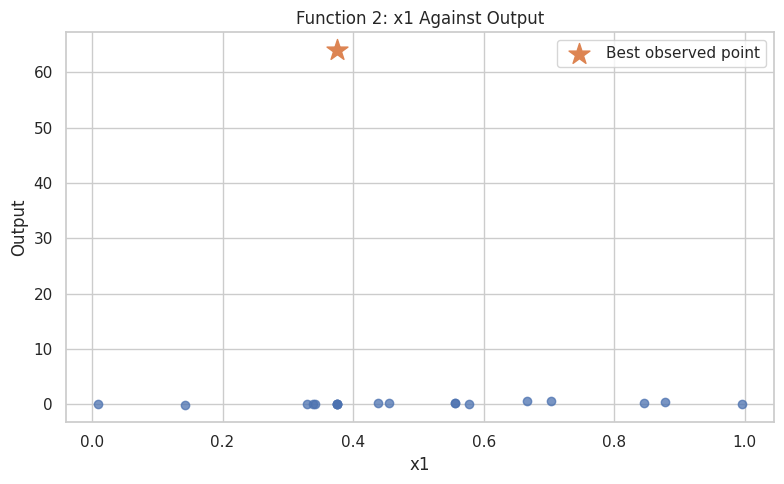

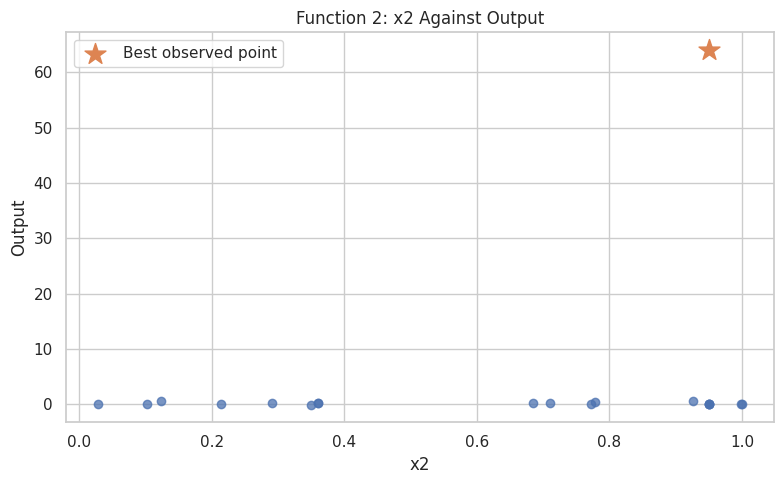


Input-output correlations
----------------------------------------
x2    0.219113
x1   -0.099515
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 20
Input dimensions   : 2
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 3
Minimum output     : -0.06562362444
Mean output        : 3.34319984
Median output      : 0.04940643322
Maximum output     : 64
Best observation   : 14
Best query point   : [0.37454  0.950714]
Best output        : 64


In [13]:
# Conduct Function 2 EDA
eda_2 = conduct_function_eda(
    function_number=2,
    dataset_folder=week_11_folder
)



FUNCTION 3 EDA

Dataset structure
----------------------------------------
Input shape : (25, 3)
Output shape: (25,)
Observations: 25
Dimensions  : 3

First five observations
----------------------------------------


,x1,x2,x3,output
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008



Missing values
----------------------------------------
x1        0
x2        0
x3        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
3

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,25.0,0.429068,0.212568,0.046809,0.242114,0.444444,0.522711,0.965995,0.444444,0.045185,0.307429
x2,25.0,0.530918,0.232331,0.090709,0.343917,0.658930,0.666666,0.941360,0.658930,0.053978,-0.454085
x3,25.0,0.382815,0.220927,0.066089,0.269363,0.333333,0.451242,0.990882,0.333333,0.048809,1.588386
output,25.0,10.161033,23.981884,-0.398926,-0.110621,-0.057397,-0.040908,64.000000,-0.057397,575.130741,1.975372



Best observed result
----------------------------------------
Best array index       : 15
Best observation number: 16
Best query point       : [0.444444 0.666666 0.333333]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,output
15,0.444444,0.666666,0.333333,64.000000
17,0.444444,0.666666,0.333333,64.000000
18,0.444444,0.666666,0.333333,64.000000
16,0.444444,0.666666,0.333333,64.000000
3,0.492581,0.611593,0.340176,-0.034835


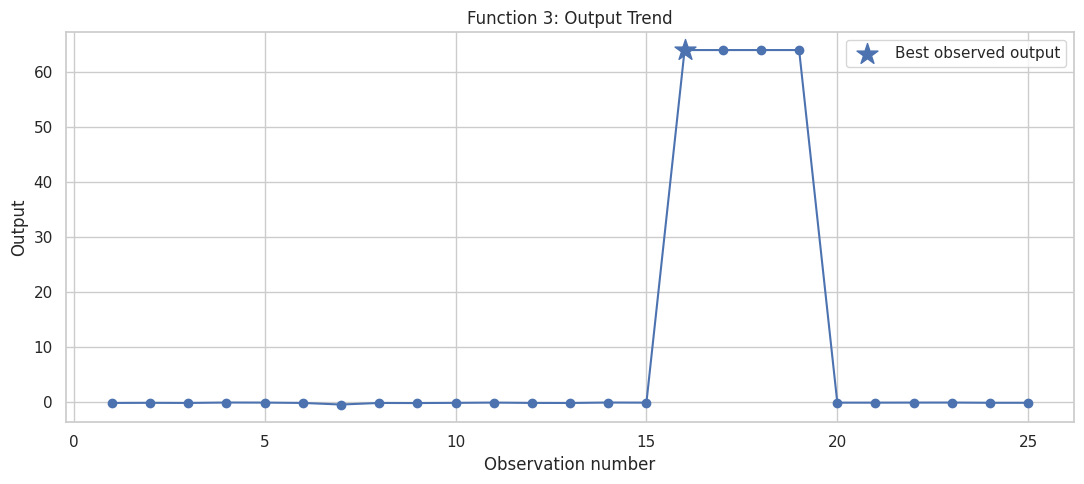

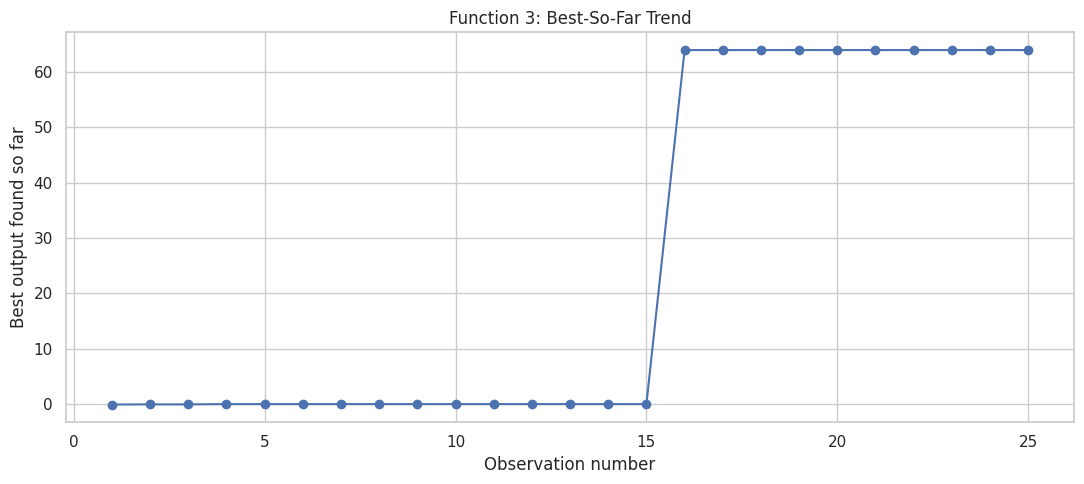

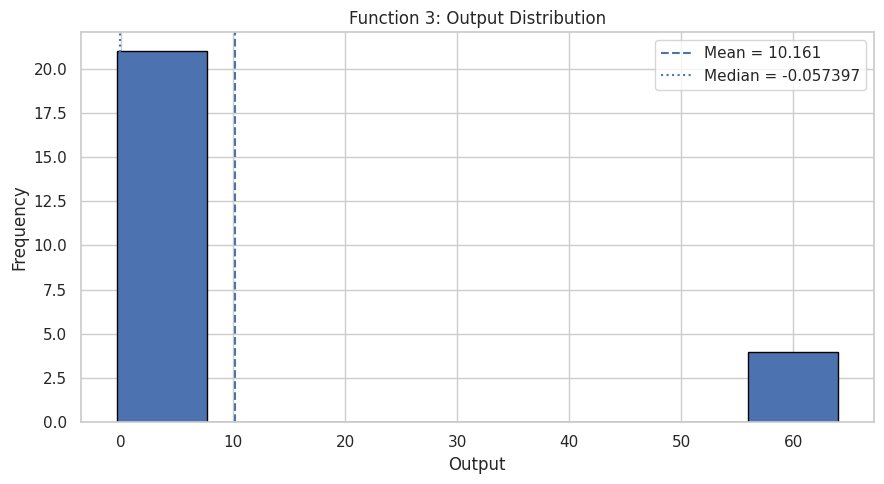

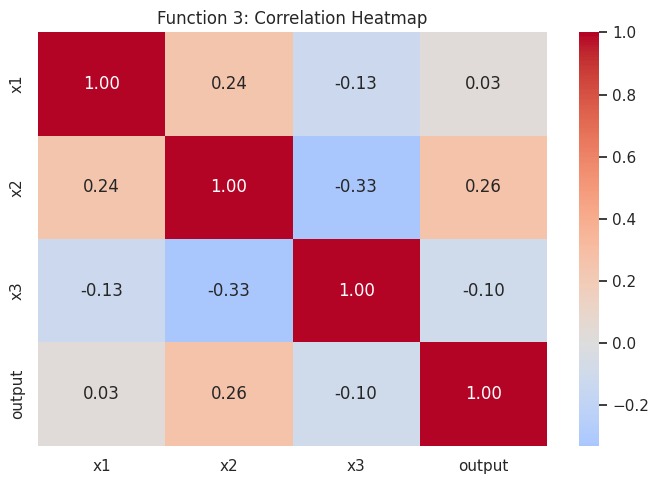

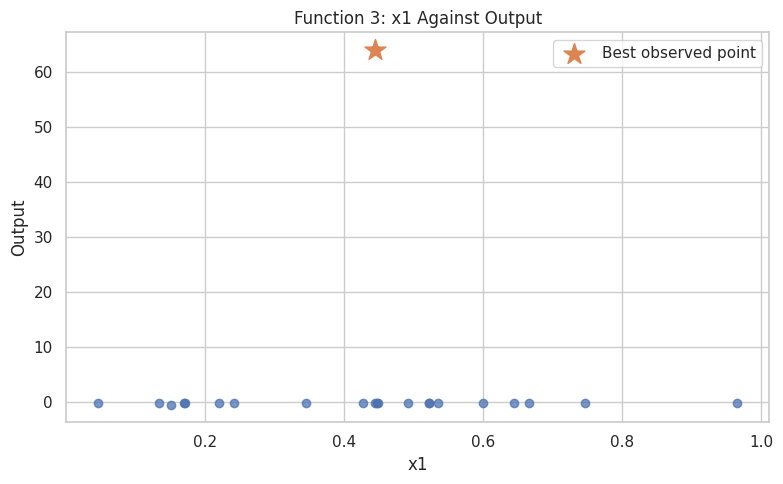

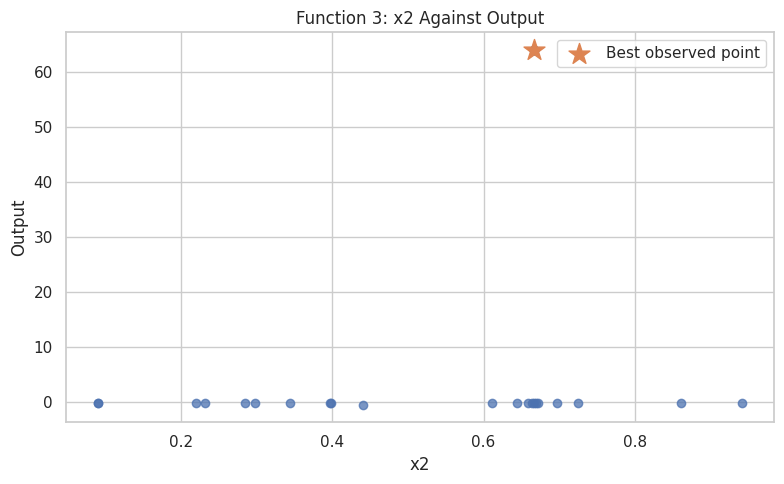

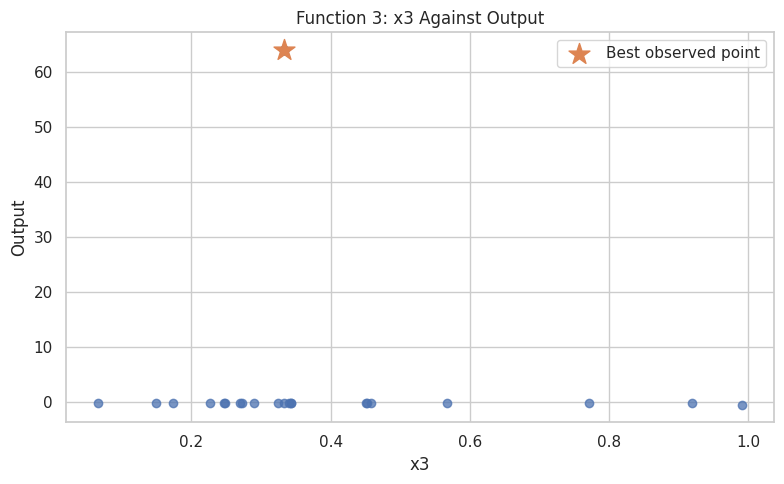


Input-output correlations
----------------------------------------
x2    0.260502
x3   -0.101371
x1    0.033005
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 25
Input dimensions   : 3
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 3
Minimum output     : -0.3989255131
Mean output        : 10.16103294
Median output      : -0.05739710167
Maximum output     : 64
Best observation   : 16
Best query point   : [0.444444 0.666666 0.333333]
Best output        : 64


In [14]:
# Conduct Function 3 EDA
eda_3 = conduct_function_eda(
    function_number=3,
    dataset_folder=week_11_folder
)



FUNCTION 4 EDA

Dataset structure
----------------------------------------
Input shape : (40, 4)
Output shape: (40,)
Observations: 40
Dimensions  : 4

First five observations
----------------------------------------


,x1,x2,x3,x4,output
0,0.896981,0.725628,0.175404,0.701694,-22.108288
1,0.889356,0.499588,0.539269,0.508783,-14.601397
2,0.250946,0.033693,0.145380,0.494932,-11.699932
3,0.346962,0.006250,0.760564,0.613024,-16.053765
4,0.124871,0.129770,0.384400,0.287076,-10.069633



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
3

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,40.0,0.551623,0.271972,0.037825,0.315091,0.566660,0.740635,0.985622,0.566660,0.073969,-0.216853
x2,40.0,0.436975,0.290491,0.002958,0.160877,0.458405,0.665373,0.919592,0.458405,0.084385,0.011911
x3,40.0,0.390879,0.269326,0.014095,0.198455,0.352386,0.576240,0.939178,0.352386,0.072536,0.451282
x4,40.0,0.394991,0.306343,0.032616,0.111111,0.270500,0.707228,0.999483,0.270500,0.093846,0.462312
output,40.0,-14.121867,14.966244,-32.625660,-20.673962,-16.040082,-11.666385,64.000000,-16.040082,223.988464,3.735920



Best observed result
----------------------------------------
Best array index       : 33
Best observation number: 34
Best query point       : [0.555555 0.444444 0.222222 0.111111]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,x4,output
33,0.555555,0.444444,0.222222,0.111111,64.000000
32,0.555555,0.444444,0.222222,0.111111,-0.031830
31,0.555555,0.444444,0.222222,0.111111,-0.031830
30,0.555555,0.444444,0.222222,0.111111,-0.031830
27,0.577766,0.428772,0.425826,0.249007,-4.025542


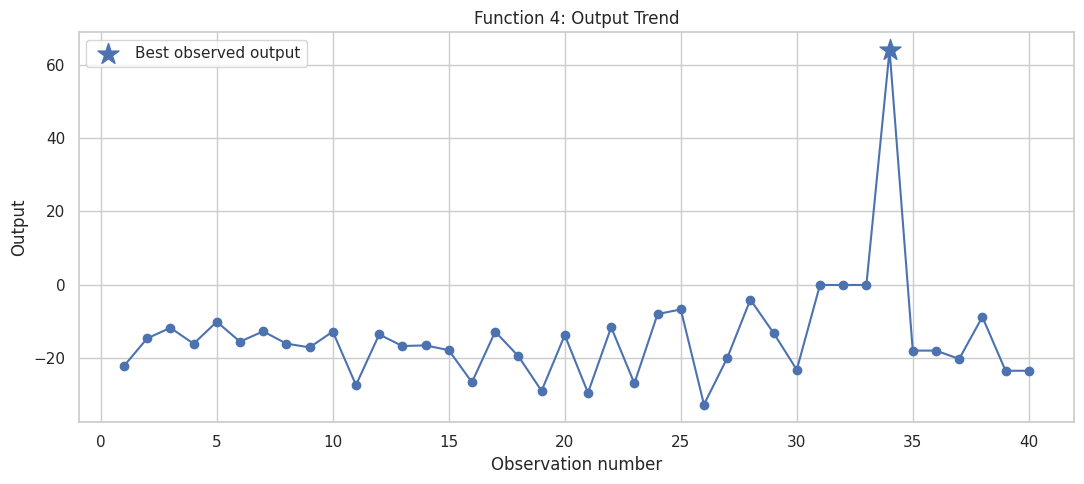

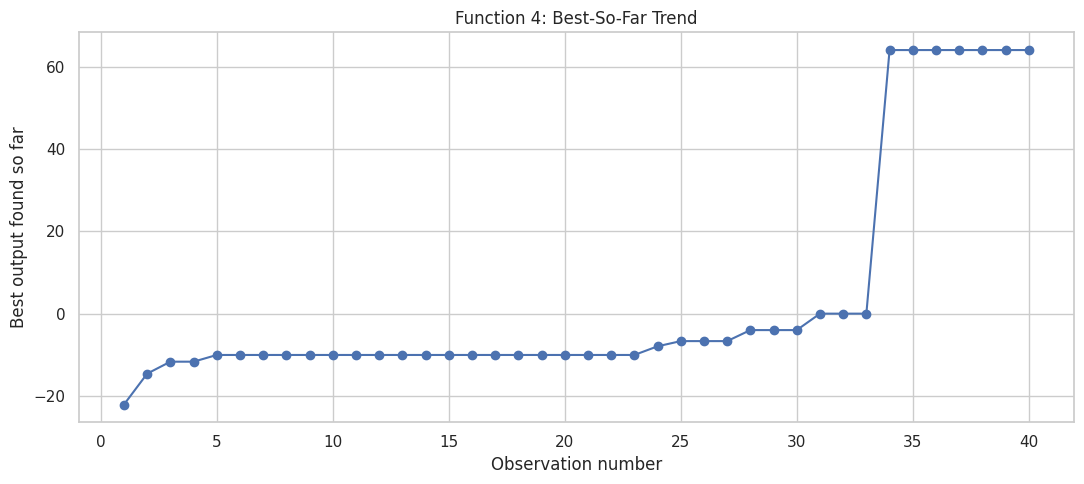

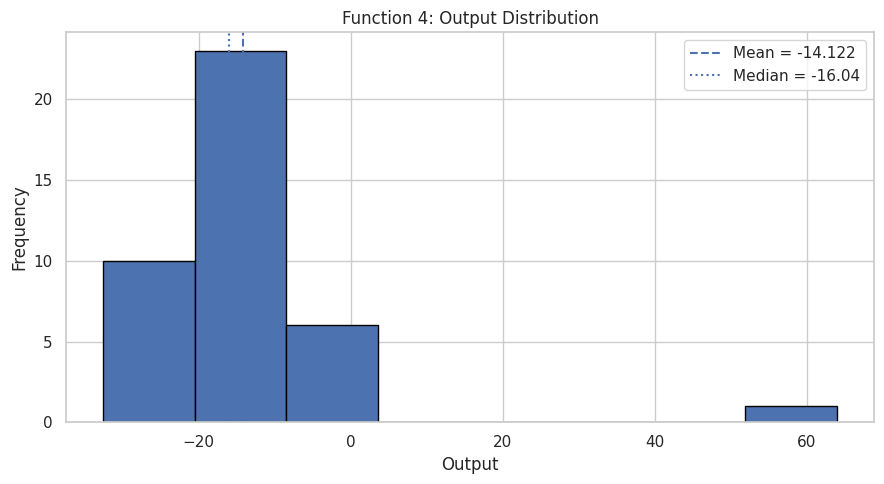

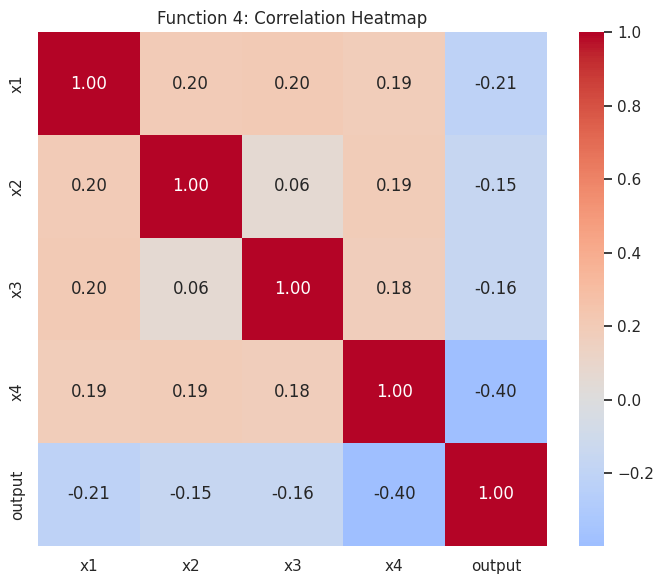

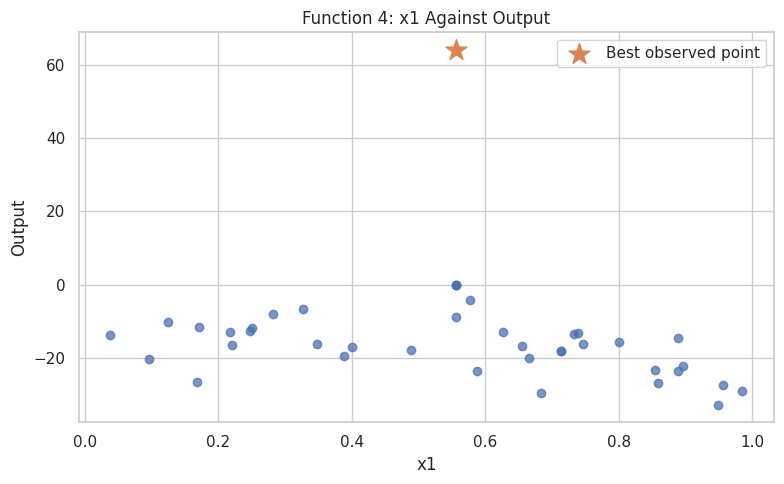

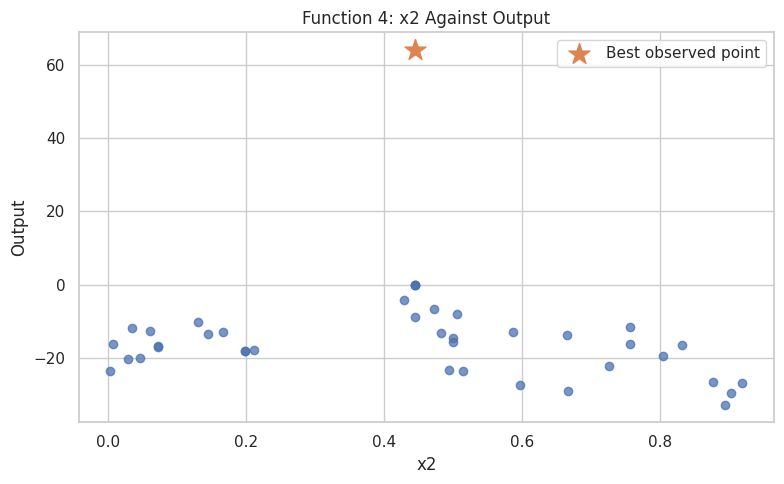

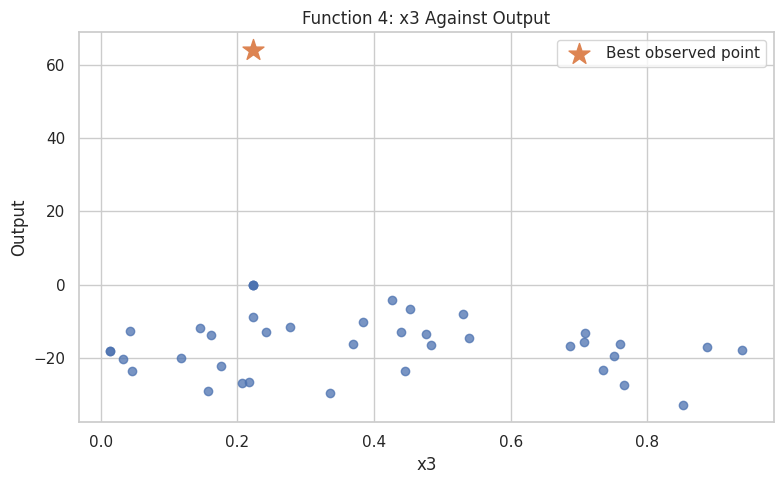

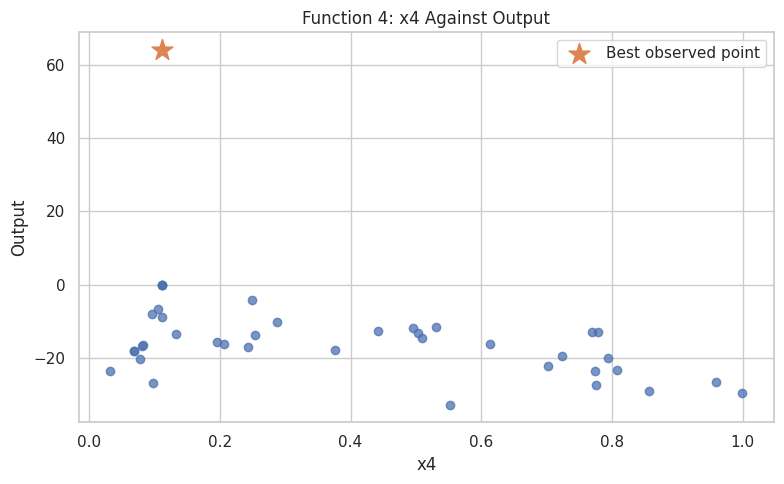


Input-output correlations
----------------------------------------
x4   -0.397402
x1   -0.210974
x3   -0.159453
x2   -0.154544
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 40
Input dimensions   : 4
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 3
Minimum output     : -32.62566022
Mean output        : -14.12186747
Median output      : -16.04008244
Maximum output     : 64
Best observation   : 34
Best query point   : [0.555555 0.444444 0.222222 0.111111]
Best output        : 64


In [15]:
# Conduct Function 4 EDA
eda_4 = conduct_function_eda(
    function_number=4,
    dataset_folder=week_11_folder
)



FUNCTION 5 EDA

Dataset structure
----------------------------------------
Input shape : (30, 4)
Output shape: (30,)
Observations: 30
Dimensions  : 4

First five observations
----------------------------------------


,x1,x2,x3,x4,output
0,0.191447,0.038193,0.607418,0.414584,64.443440
1,0.758653,0.536518,0.656000,0.360342,18.301380
2,0.438350,0.804340,0.210245,0.151295,0.112940
3,0.706051,0.534192,0.264243,0.482088,4.210898
4,0.836478,0.193610,0.663893,0.785649,258.370525



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
4

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,30.0,0.405446,0.247812,0.00000,0.224189,0.353919,0.654112,0.836478,0.353919,0.061411,0.199893
x2,30.0,0.560228,0.285881,0.00000,0.331309,0.634822,0.839349,0.918769,0.634822,0.081728,-0.575394
x3,30.0,0.531549,0.272784,0.00000,0.355615,0.543505,0.759799,0.879484,0.543505,0.074411,-0.272486
x4,30.0,0.562969,0.333136,0.00000,0.307039,0.524832,0.878515,1.000000,0.524832,0.110980,-0.227582
output,30.0,179.896667,281.174255,0.11294,25.534004,64.000000,215.698333,1088.859618,64.000000,79058.961469,2.483084



Best observed result
----------------------------------------
Best array index       : 15
Best observation number: 16
Best query point       : [0.22418902 0.84648049 0.87948418 0.87851568]
Best output value      : 1088.8596181962705

Top five observations
----------------------------------------


,x1,x2,x3,x4,output
15,0.224189,0.846480,0.879484,0.878516,1088.859618
27,0.224189,0.846480,0.879484,0.878515,1088.853511
18,0.119879,0.862540,0.643331,0.849804,431.612757
28,0.319924,0.675406,0.431628,1.000000,430.803125
29,0.005552,0.918769,0.692571,0.988052,430.803125


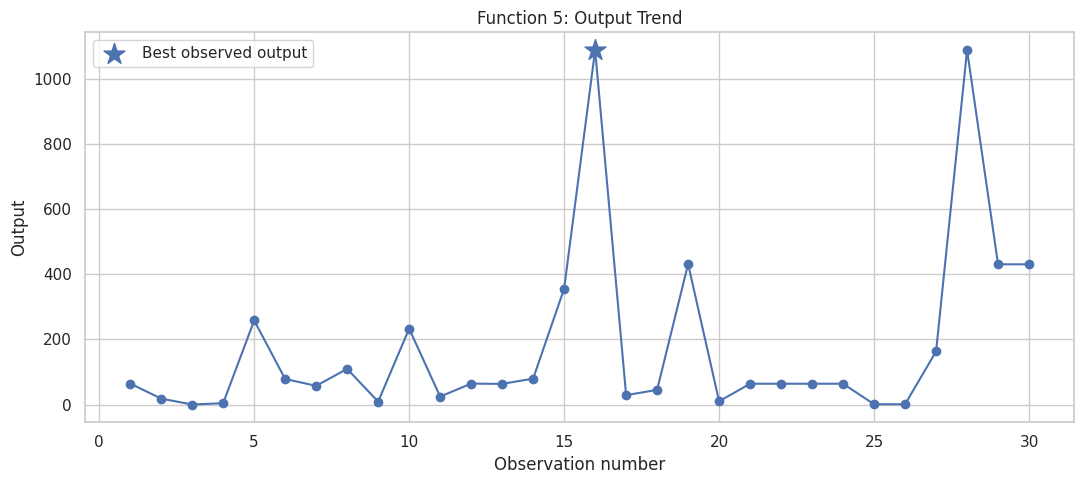

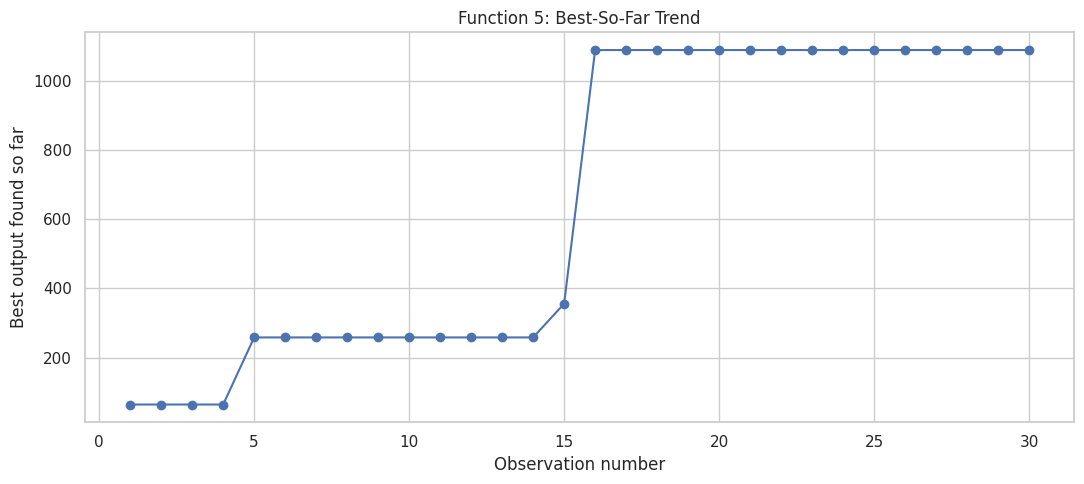

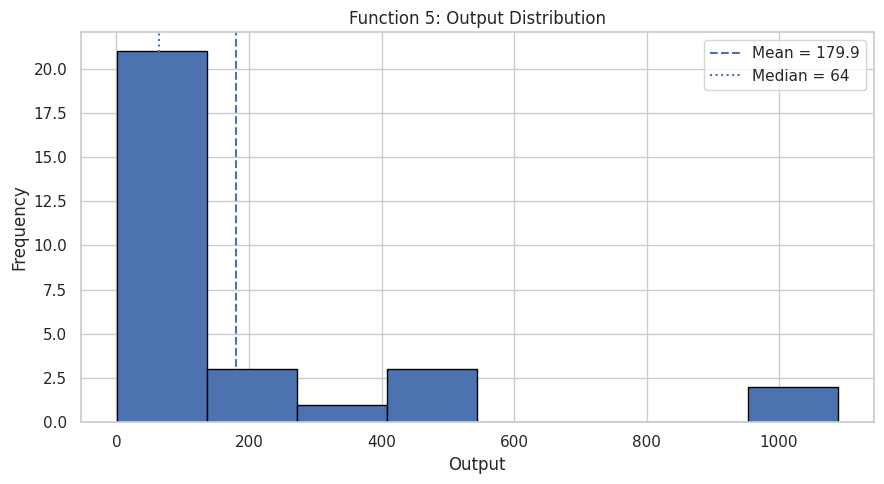

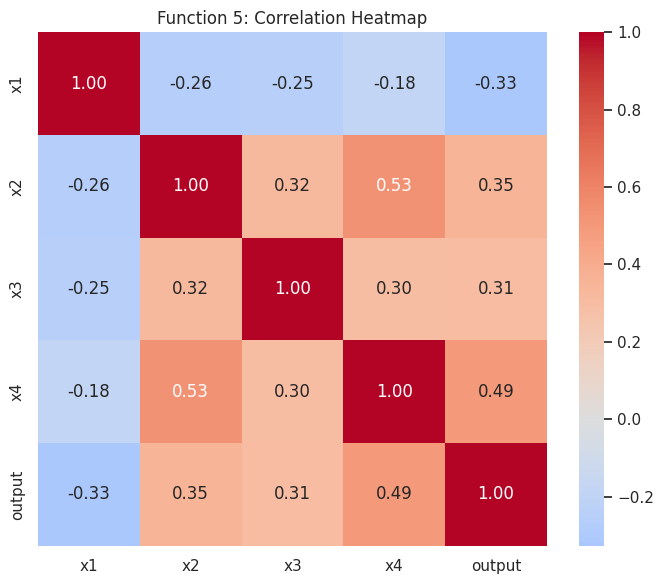

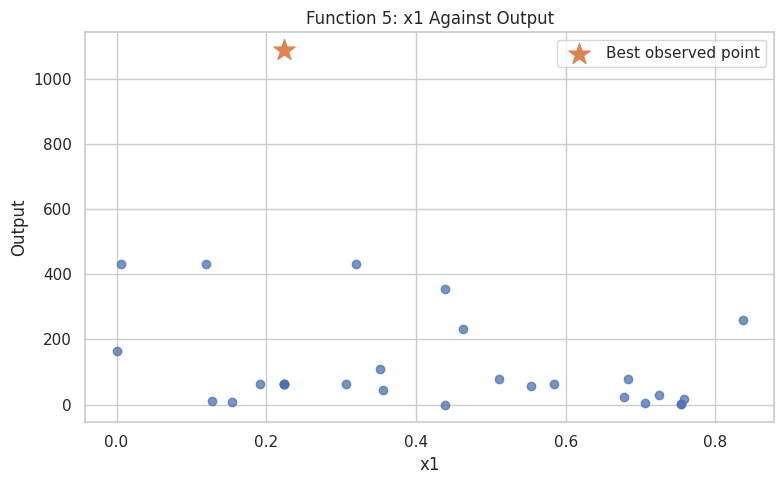

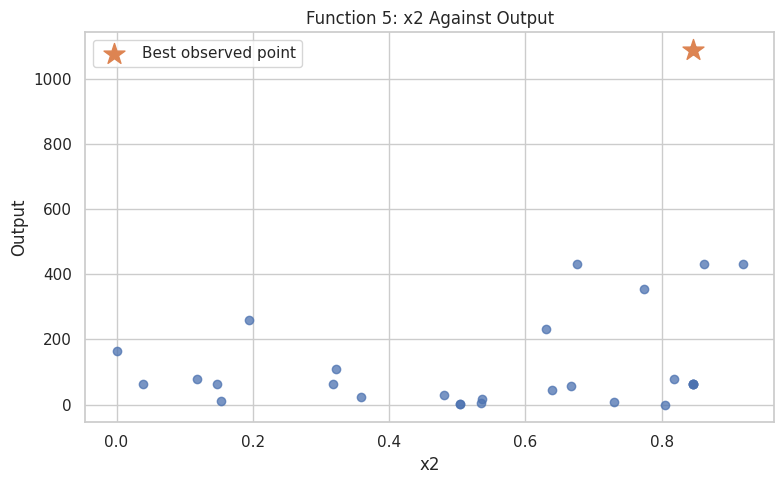

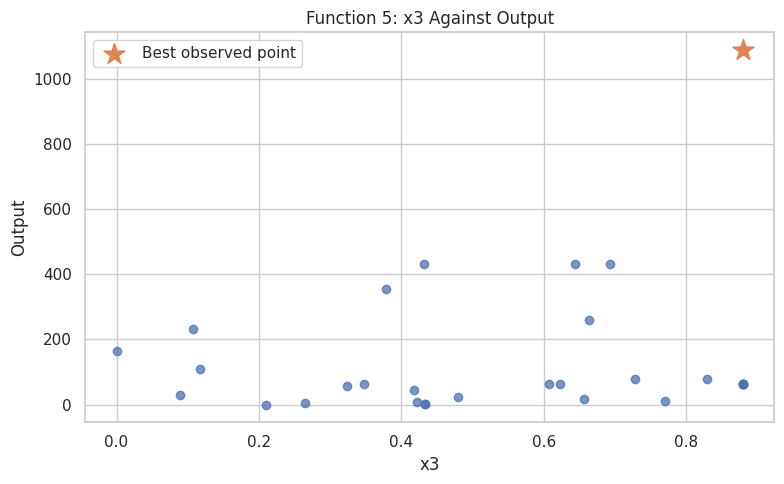

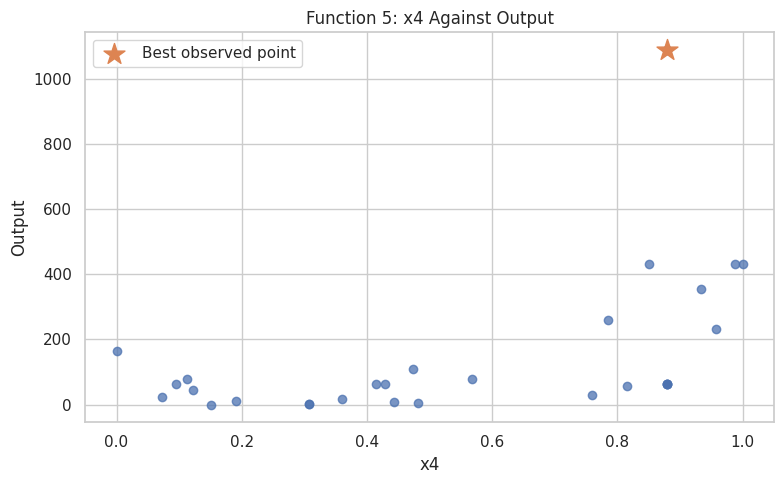


Input-output correlations
----------------------------------------
x4    0.492732
x2    0.352175
x1   -0.327331
x3    0.305322
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 30
Input dimensions   : 4
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 4
Minimum output     : 0.1129397954
Mean output        : 179.8966669
Median output      : 64
Maximum output     : 1088.859618
Best observation   : 16
Best query point   : [0.22418902 0.84648049 0.87948418 0.87851568]
Best output        : 1088.859618


In [16]:
# Conduct Function 5 EDA
eda_5 = conduct_function_eda(
    function_number=5,
    dataset_folder=week_11_folder
)



FUNCTION 6 EDA

Dataset structure
----------------------------------------
Input shape : (30, 5)
Output shape: (30,)
Observations: 30
Dimensions  : 5

First five observations
----------------------------------------


,x1,x2,x3,x4,x5,output
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
3

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,30.0,0.616445,0.266347,0.021735,0.463707,0.728186,0.779815,0.957740,0.728186,0.070941,-0.976304
x2,30.0,0.414442,0.315193,0.022732,0.154693,0.300126,0.739984,0.931871,0.300126,0.099347,0.465953
x3,30.0,0.571529,0.300939,0.016523,0.412629,0.704408,0.736935,0.978806,0.704408,0.090565,-0.672642
x4,30.0,0.540897,0.273608,0.041715,0.364471,0.679768,0.693997,0.961656,0.679768,0.074861,-0.620940
x5,30.0,0.496438,0.273149,0.004911,0.287370,0.564013,0.625723,0.897560,0.564013,0.074611,-0.455714
output,30.0,0.804273,11.953762,-2.571170,-1.700504,-1.290668,-1.146597,64.000000,-1.290668,142.892422,5.450805



Best observed result
----------------------------------------
Best array index       : 23
Best observation number: 24
Best query point       : [0.728186 0.154693 0.732552 0.693997 0.564013]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,x4,x5,output
23,0.728186,0.154693,0.732552,0.693997,0.564013,64.000000
20,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
21,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
22,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265


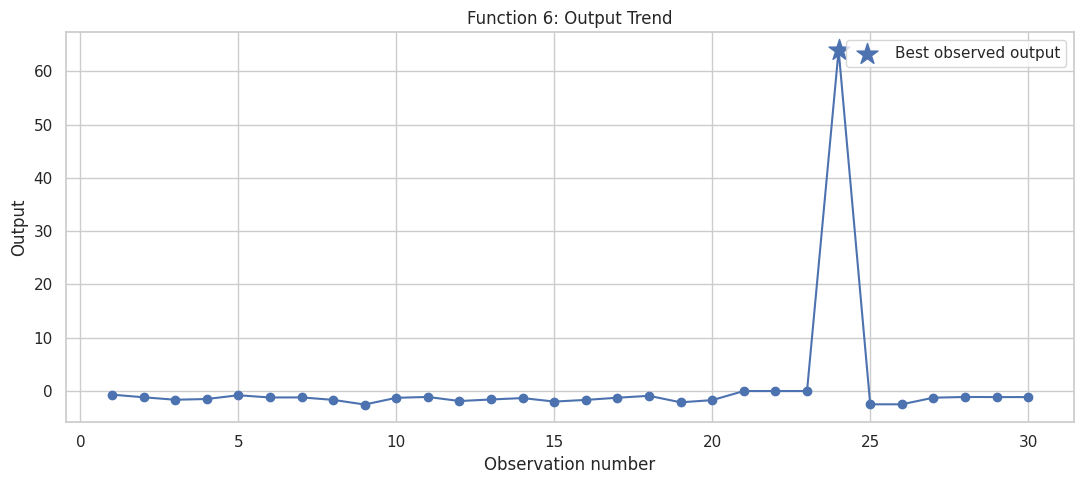

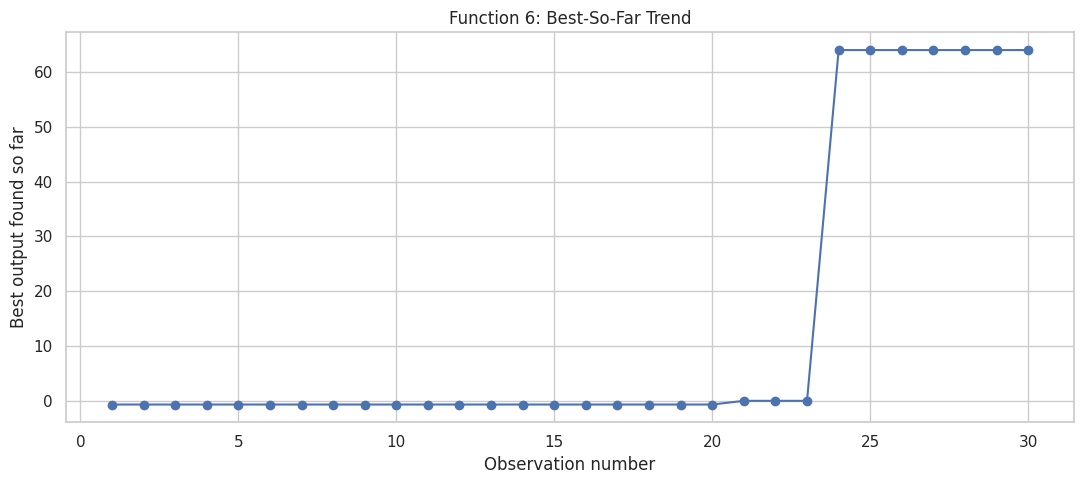

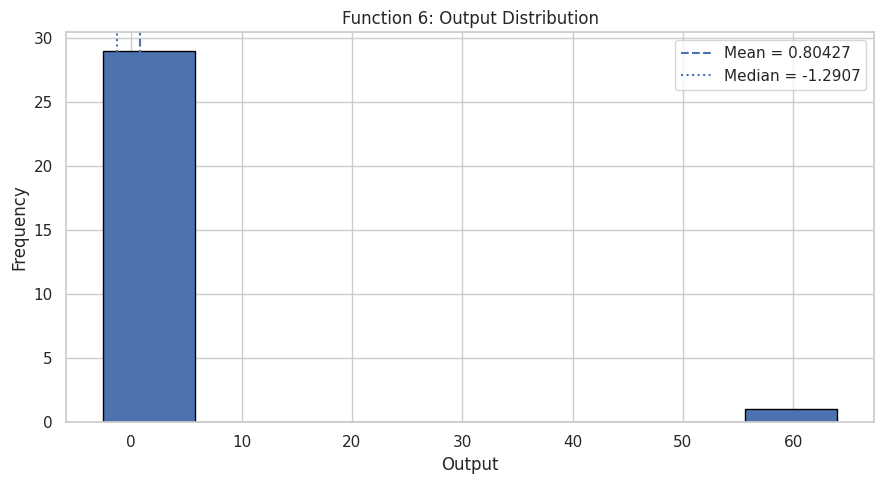

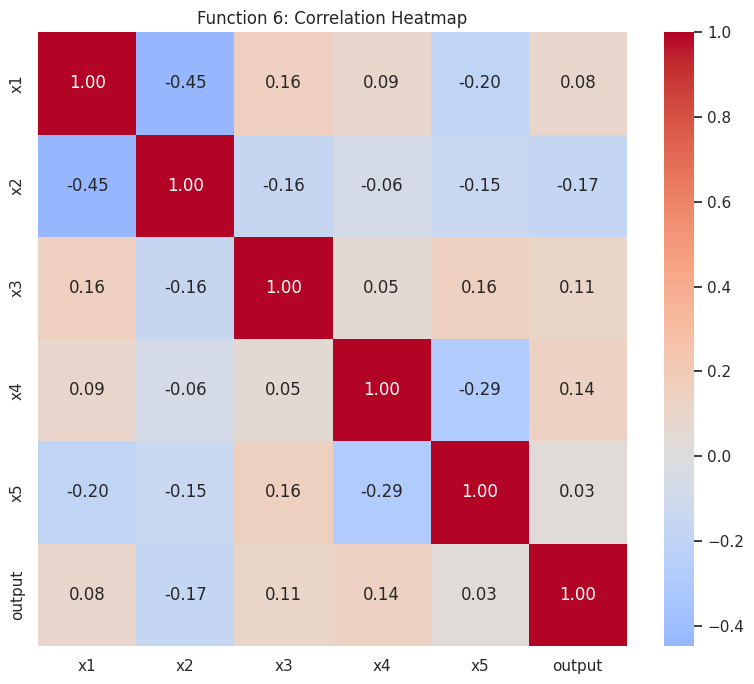

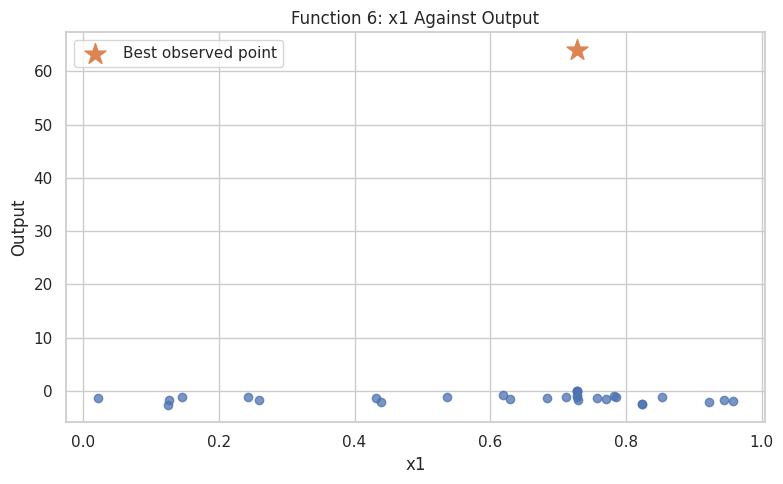

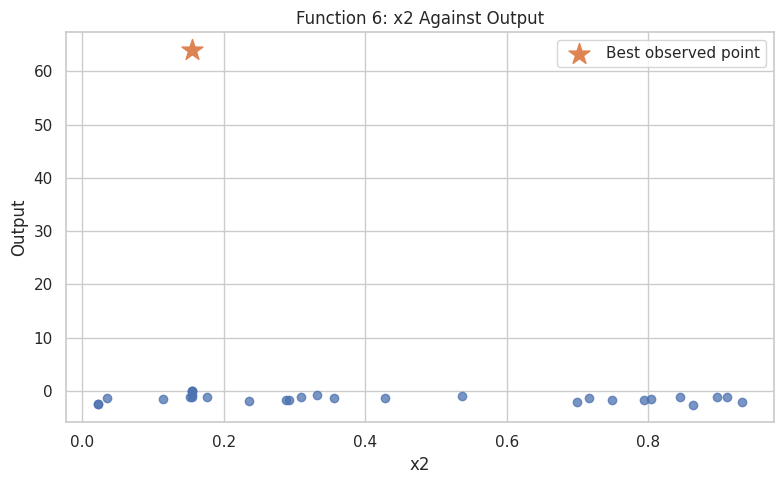

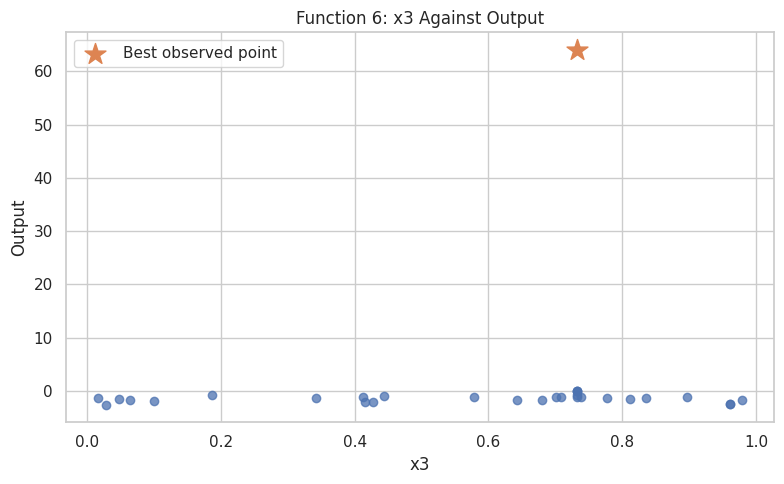

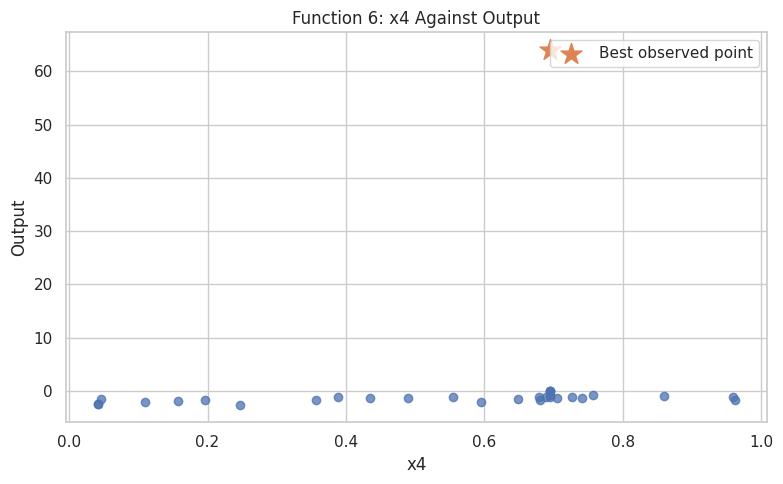

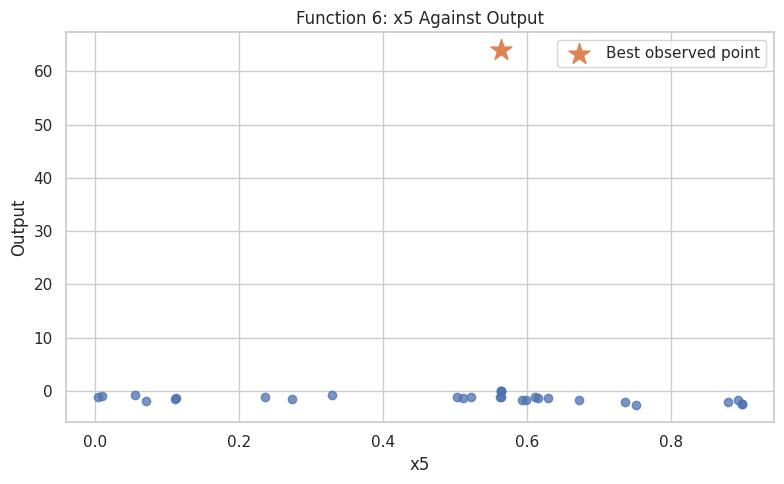


Input-output correlations
----------------------------------------
x2   -0.169190
x4    0.138861
x3    0.108810
x1    0.084362
x5    0.026206
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 30
Input dimensions   : 5
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 3
Minimum output     : -2.571169632
Mean output        : 0.8042729702
Median output      : -1.290668212
Maximum output     : 64
Best observation   : 24
Best query point   : [0.728186 0.154693 0.732552 0.693997 0.564013]
Best output        : 64


In [17]:
# Conduct Function 6 EDA
eda_6 = conduct_function_eda(
    function_number=6,
    dataset_folder=week_11_folder
)



FUNCTION 7 EDA

Dataset structure
----------------------------------------
Input shape : (40, 6)
Output shape: (40,)
Observations: 40
Dimensions  : 6

First five observations
----------------------------------------


,x1,x2,x3,x4,x5,x6,output
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
3

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,40.0,0.396898,0.330004,0.018603,0.073401,0.296217,0.723533,0.942451,0.296217,0.108903,0.307120
x2,40.0,0.450972,0.250067,0.011813,0.307063,0.505885,0.564890,0.924694,0.505885,0.062533,0.002983
x3,40.0,0.393986,0.283031,0.003635,0.217435,0.329265,0.626816,0.924571,0.329265,0.080107,0.384058
x4,40.0,0.408093,0.325982,0.037758,0.105350,0.271793,0.737994,0.961017,0.271793,0.106264,0.559423
x5,40.0,0.455607,0.272465,0.014944,0.263148,0.434667,0.685195,0.998655,0.434667,0.074237,0.265969
x6,40.0,0.515152,0.240249,0.051100,0.357071,0.617028,0.658586,0.951014,0.617028,0.057720,-0.655471
output,40.0,6.673512,19.355501,0.002701,0.030509,0.190783,0.627430,64.000000,0.190783,374.635437,2.769978



Best observed result
----------------------------------------
Best array index       : 30
Best observation number: 31
Best query point       : [0.045091 0.528666 0.329265 0.10535  0.434667 0.641164]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,x4,x5,x6,output
30,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
31,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
33,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
32,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968


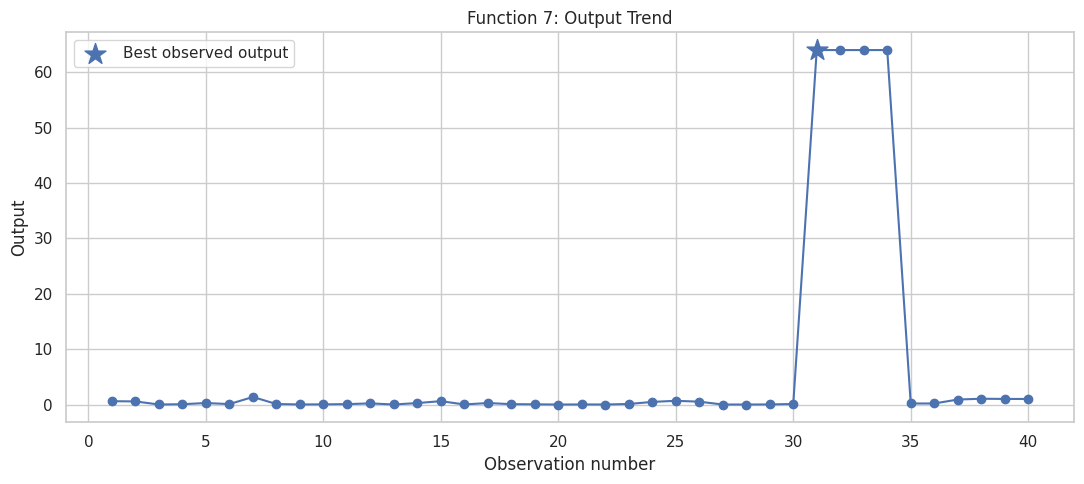

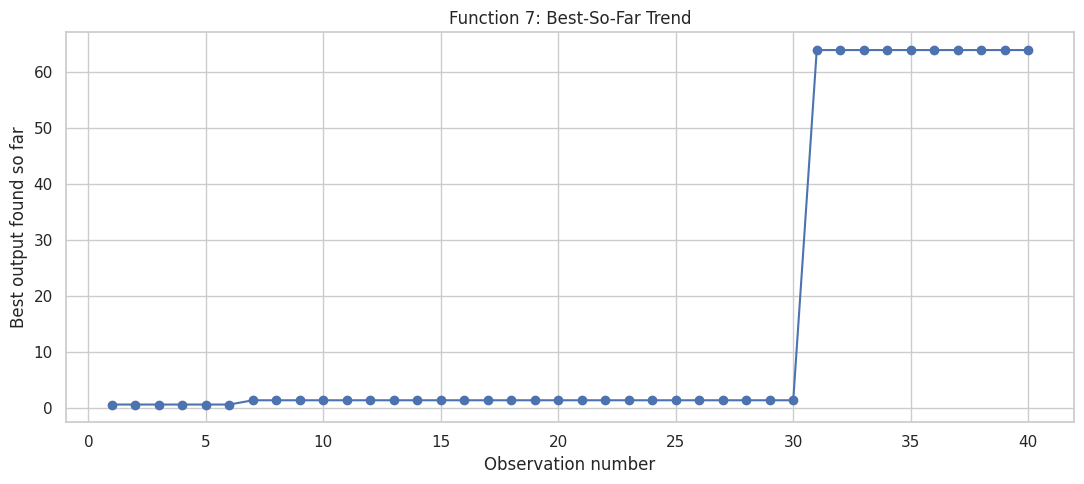

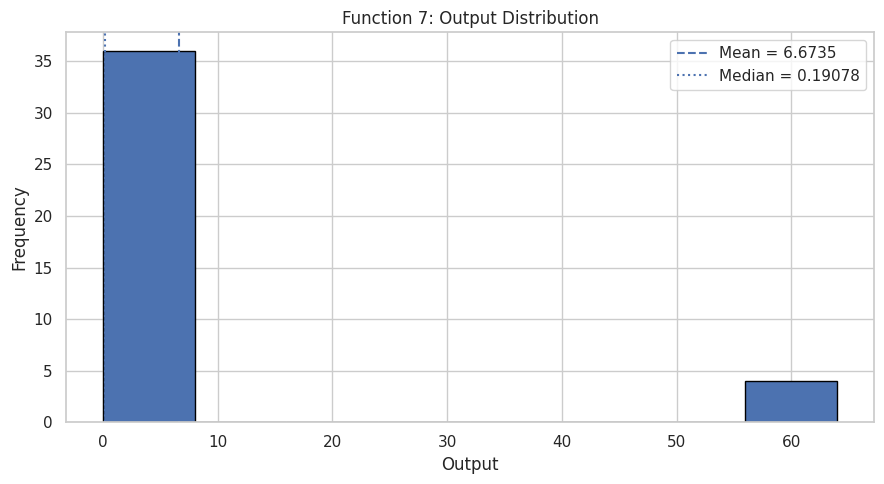

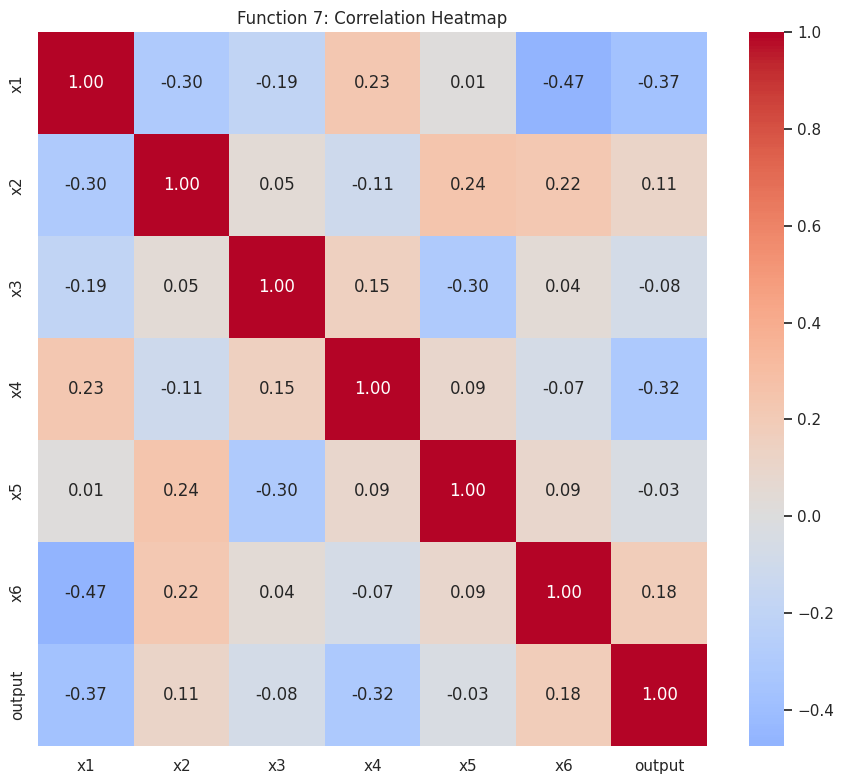

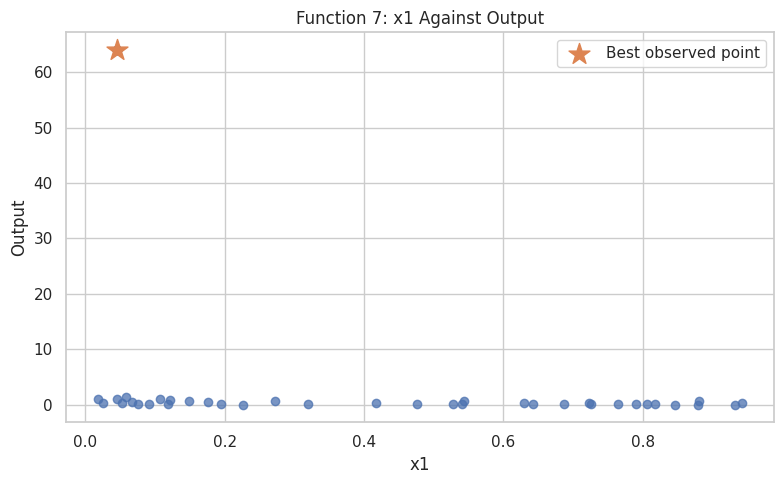

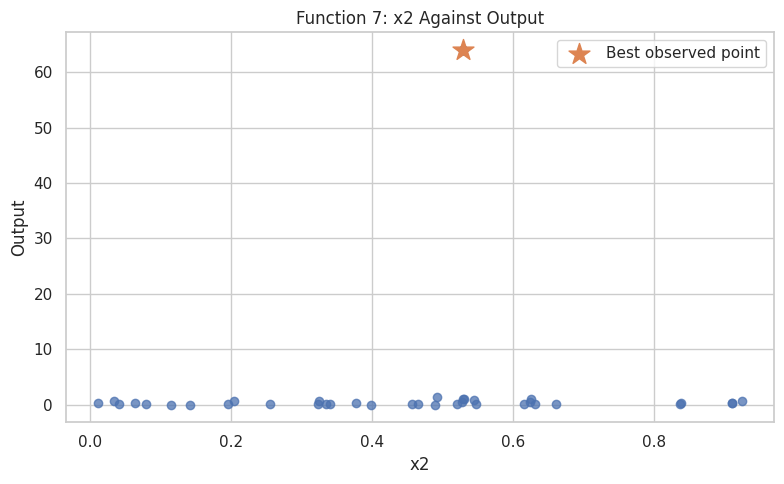

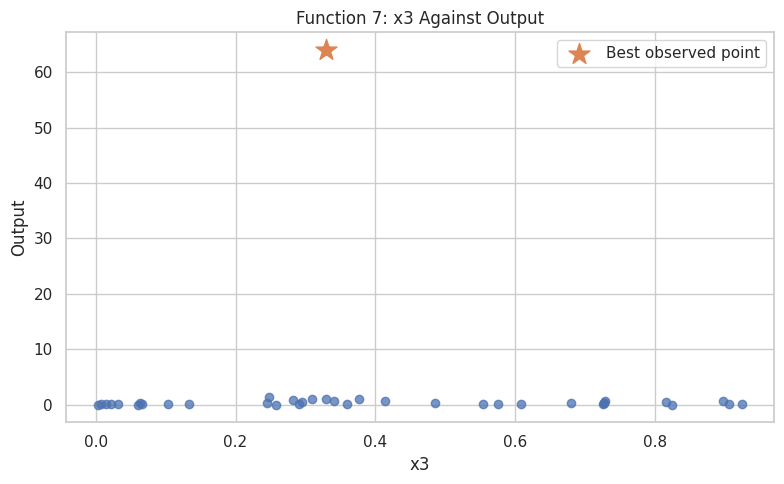

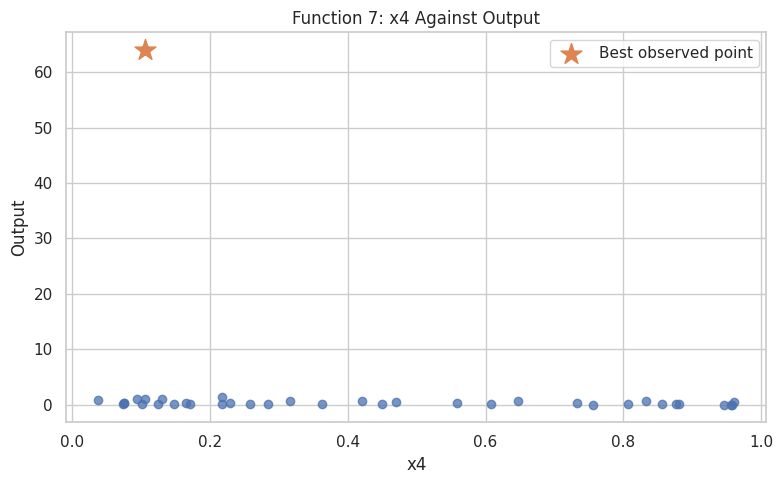

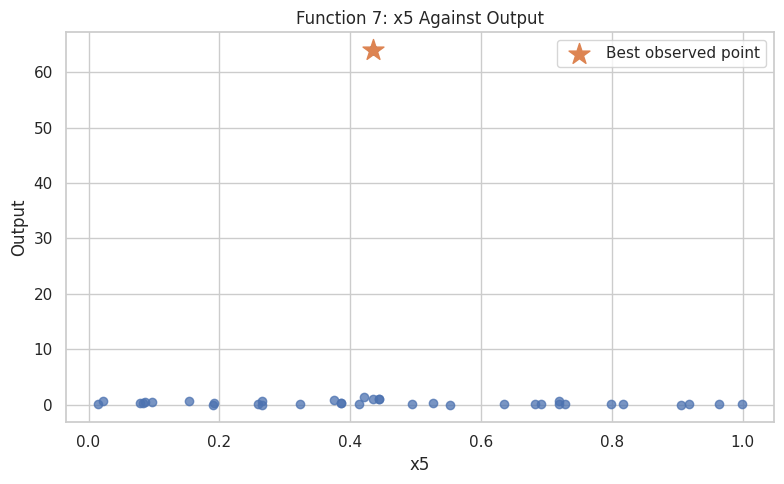

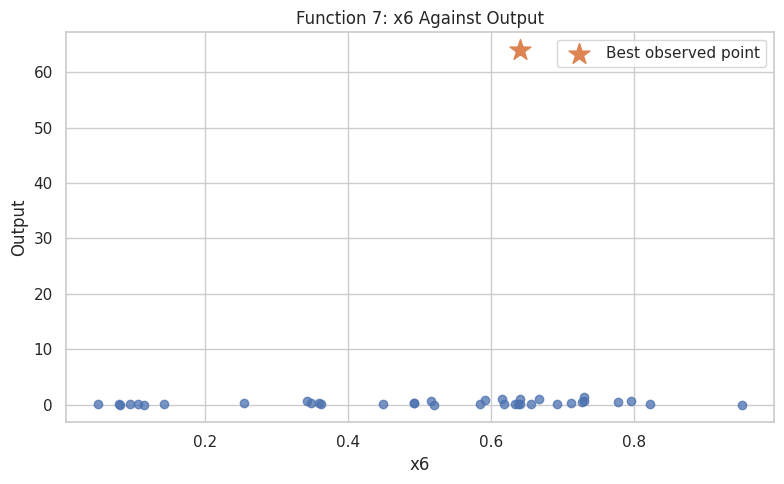


Input-output correlations
----------------------------------------
x1   -0.367994
x4   -0.318605
x6    0.183304
x2    0.107185
x3   -0.076033
x5   -0.031554
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 40
Input dimensions   : 6
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 3
Minimum output     : 0.002701465025
Mean output        : 6.673511512
Median output      : 0.1907826273
Maximum output     : 64
Best observation   : 31
Best query point   : [0.045091 0.528666 0.329265 0.10535  0.434667 0.641164]
Best output        : 64


In [18]:
# Conduct Function 7 EDA
eda_7 = conduct_function_eda(
    function_number=7,
    dataset_folder=week_11_folder
)



FUNCTION 8 EDA

Dataset structure
----------------------------------------
Input shape : (49, 8)
Output shape: (49,)
Observations: 49
Dimensions  : 8

First five observations
----------------------------------------


,x1,x2,x3,x4,x5,x6,x7,x8,output
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
x7        0
x8        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
x7        0
x8        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
2

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,49.0,0.482666,0.308170,0.006802,0.273673,0.472071,0.778345,0.985945,0.472071,0.094969,0.078196
x2,49.0,0.442291,0.297628,0.003419,0.232284,0.437736,0.653730,0.973980,0.437736,0.088583,0.179064
x3,49.0,0.454634,0.310545,0.021301,0.219486,0.382124,0.728030,0.998885,0.382124,0.096438,0.288441
x4,49.0,0.388703,0.278635,0.000000,0.098916,0.387609,0.639151,0.902986,0.387609,0.077637,0.187136
x5,49.0,0.524850,0.291764,0.009649,0.263530,0.580143,0.771803,0.986902,0.580143,0.085126,-0.134701
x6,49.0,0.424427,0.280056,0.022113,0.230729,0.309853,0.654567,0.990244,0.309853,0.078432,0.509745
x7,49.0,0.503949,0.295011,0.035909,0.230907,0.553779,0.755827,0.992914,0.553779,0.087031,-0.122447
x8,49.0,0.457180,0.279703,0.041956,0.205841,0.381734,0.674753,0.988755,0.381734,0.078234,0.240329
output,49.0,8.095287,9.152532,-8.727516,7.131624,7.957875,8.817558,64.000000,7.957875,83.768840,4.544283



Best observed result
----------------------------------------
Best array index       : 43
Best observation number: 44
Best query point       : [0.273673 0.2604   0.073937 0.078562 0.862321 0.230729 0.108688 0.110992]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,x4,x5,x6,x7,x8,output
43,0.273673,0.260400,0.073937,0.078562,0.862321,0.230729,0.108688,0.110992,64.000000
48,0.546897,0.163123,0.136484,0.078398,0.771803,0.070794,0.119397,0.111488,9.699892
47,0.321258,0.232284,0.021301,0.000000,0.895967,0.249315,0.054463,0.073967,9.699892
14,0.056447,0.065956,0.022929,0.038786,0.403935,0.801055,0.488307,0.893085,9.598482
26,0.192640,0.630677,0.416796,0.490529,0.796086,0.654567,0.276241,0.295518,9.344274


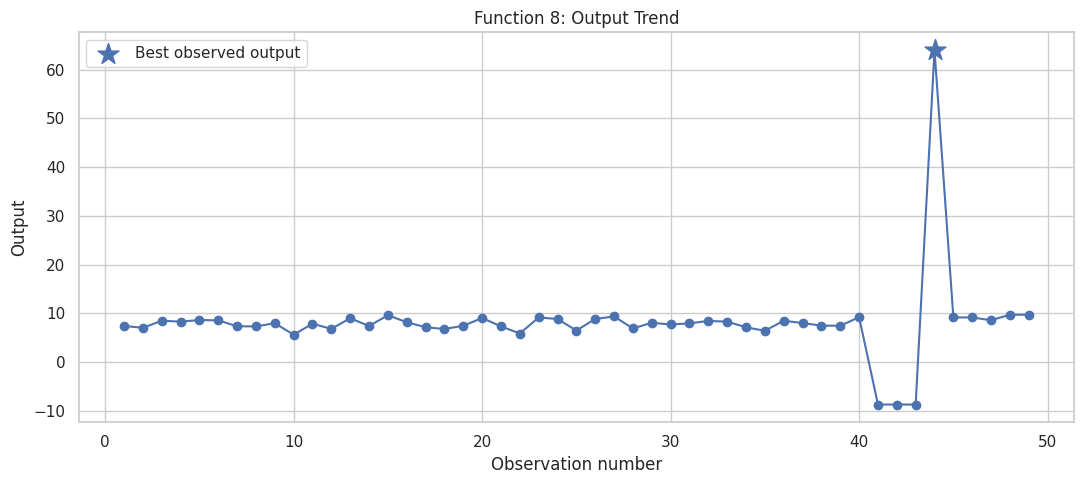

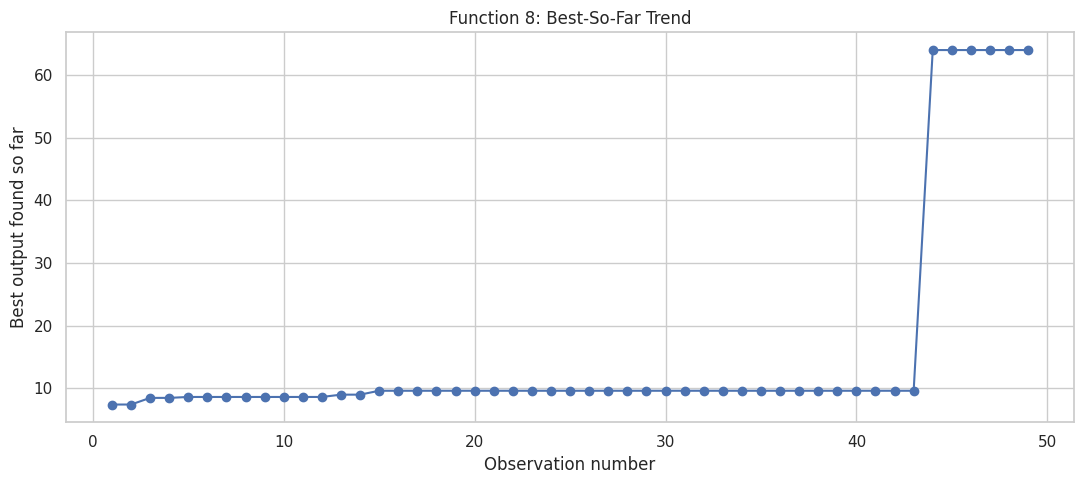

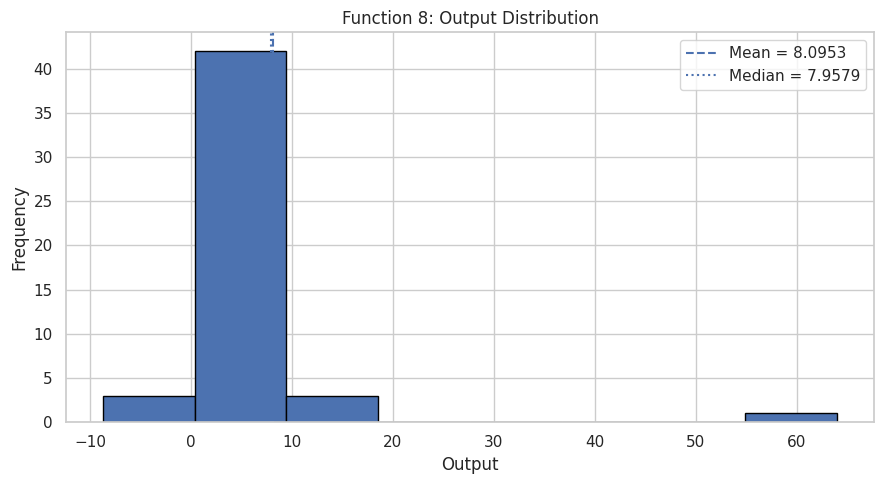

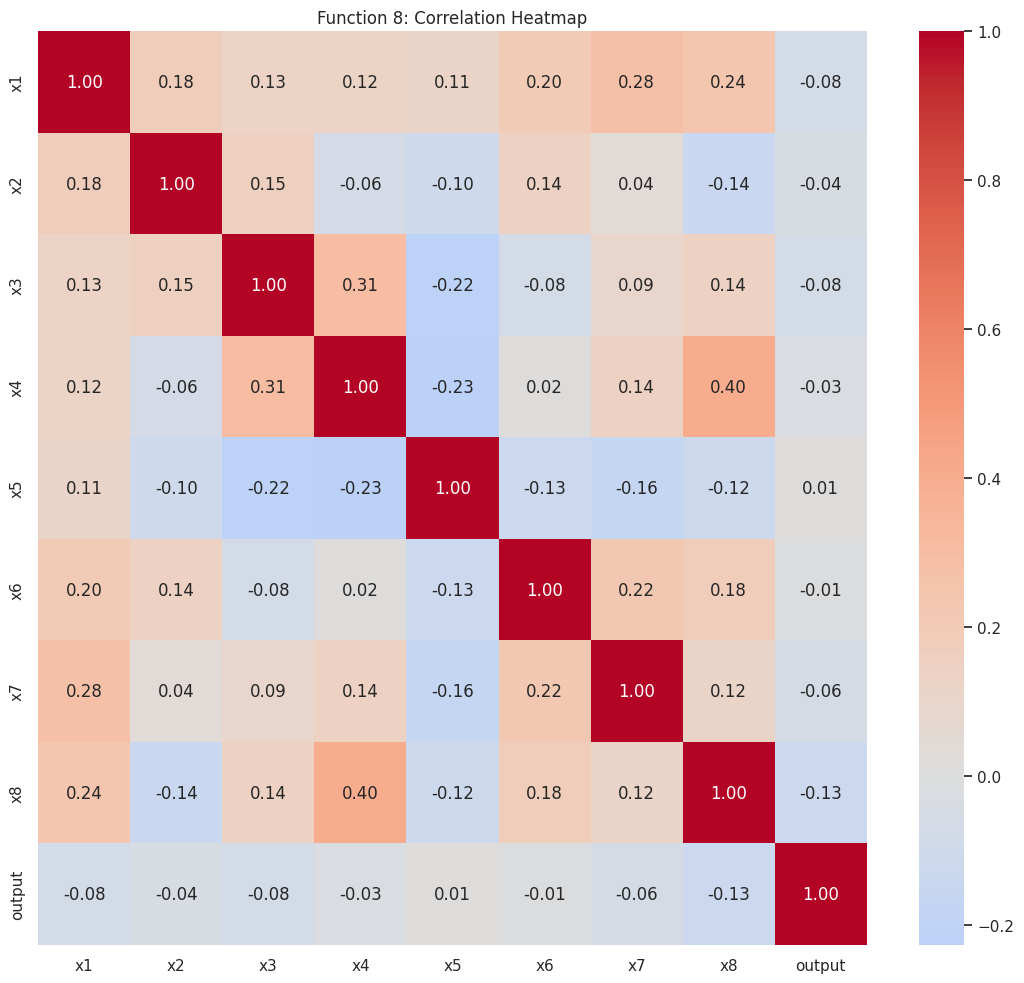

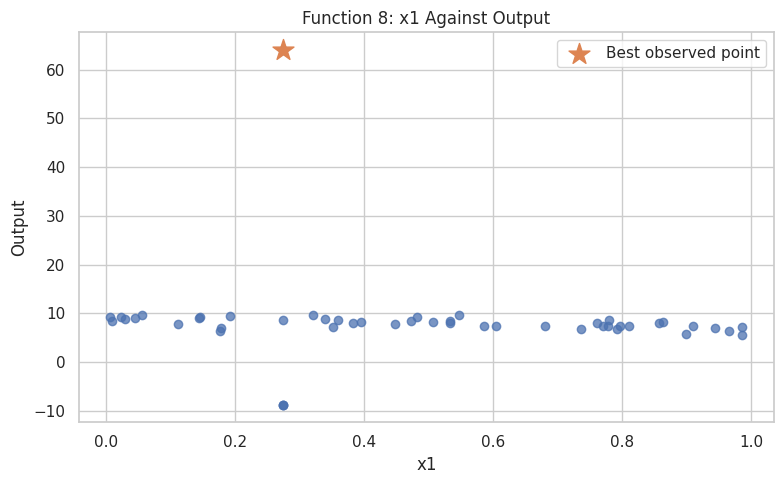

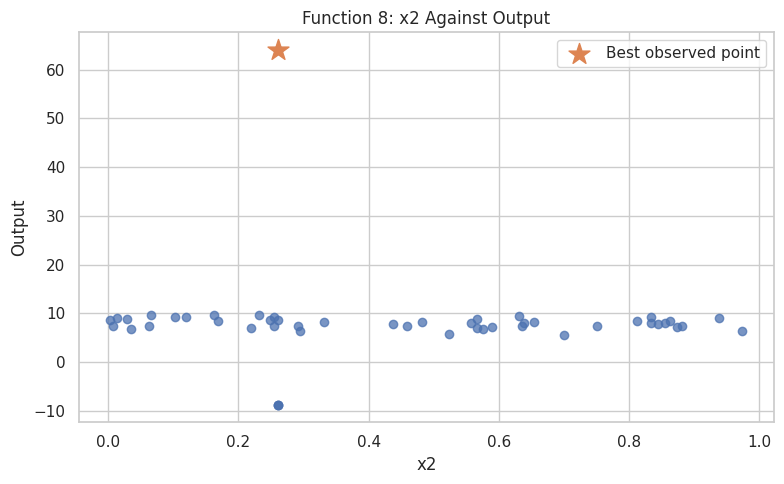

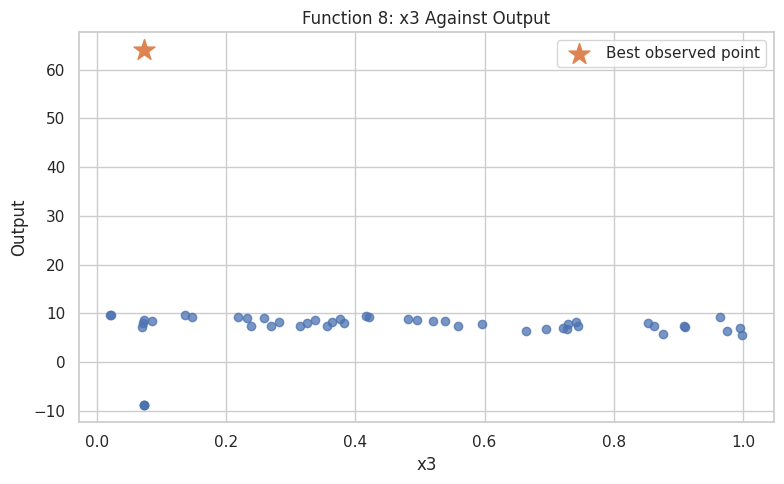

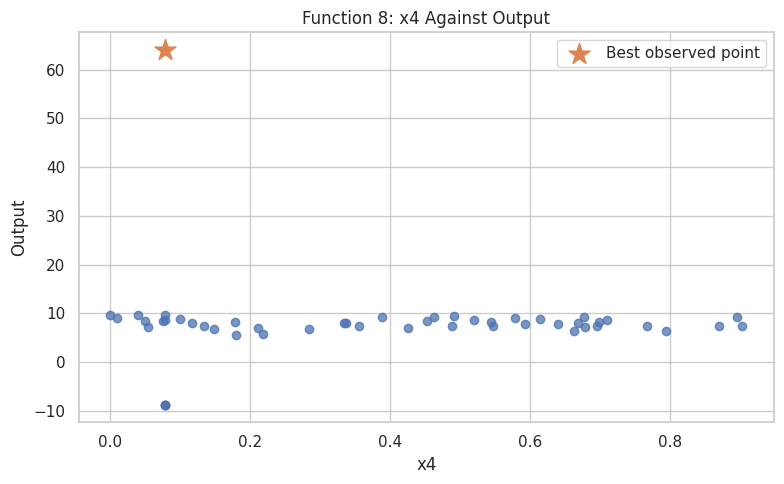

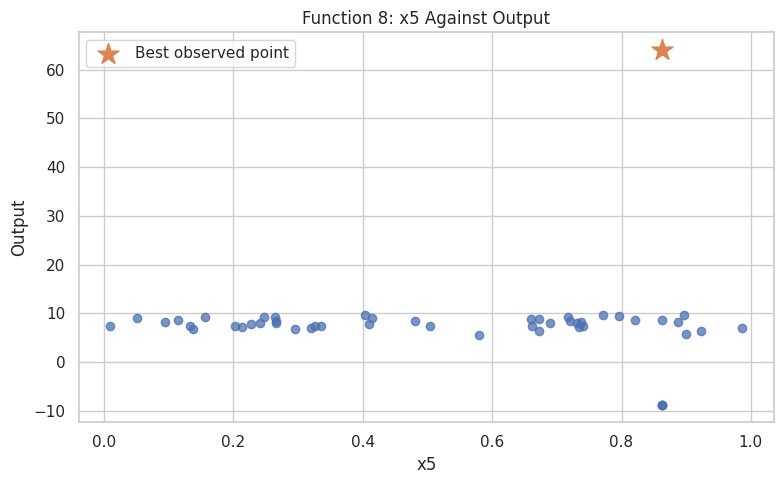

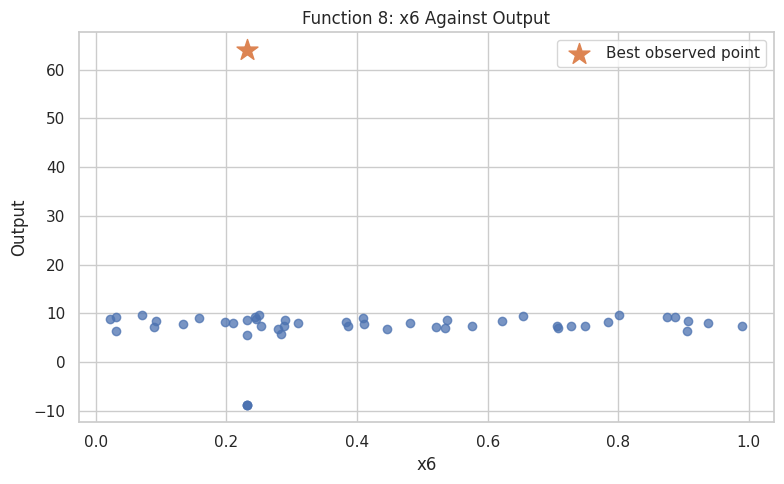

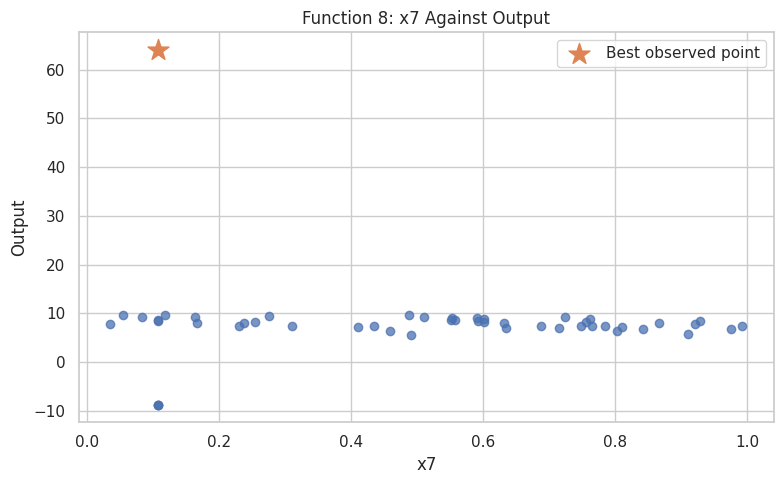

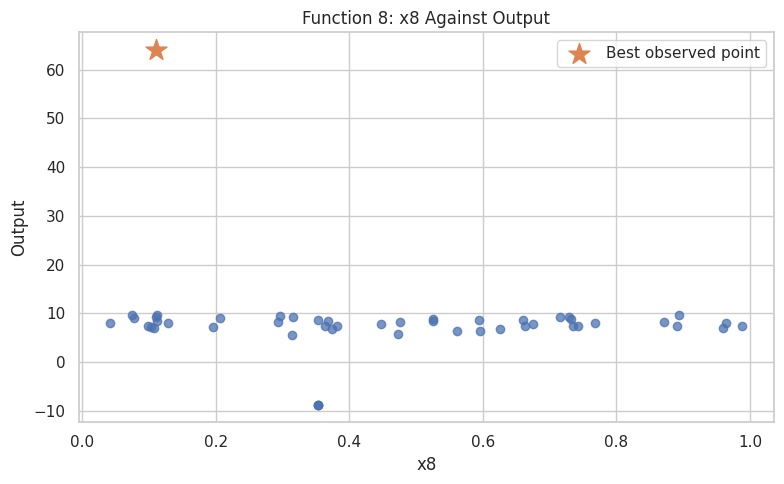


Input-output correlations
----------------------------------------
x8   -0.128540
x3   -0.077037
x1   -0.075487
x7   -0.057972
x2   -0.035993
x4   -0.028796
x5    0.013700
x6   -0.013186
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 49
Input dimensions   : 8
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 2
Minimum output     : -8.727516493
Mean output        : 8.095287145
Median output      : 7.957874742
Maximum output     : 64
Best observation   : 44
Best query point   : [0.273673 0.2604   0.073937 0.078562 0.862321 0.230729 0.108688 0.110992]
Best output        : 64


In [19]:
# Conduct Function 8 EDA
eda_8 = conduct_function_eda(
    function_number=8,
    dataset_folder=week_11_folder
)

In [20]:
all_eda_results = [
    eda_1,
    eda_2,
    eda_3,
    eda_4,
    eda_5,
    eda_6,
    eda_7,
    eda_8
]

combined_summary = []

for result in all_eda_results:

    X = result["X"]
    y = result["y"]

    combined_summary.append({
        "Function": result["function"],
        "Observations": X.shape[0],
        "Dimensions": X.shape[1],
        "Minimum_Output": np.min(y),
        "Mean_Output": np.mean(y),
        "Median_Output": np.median(y),
        "Maximum_Output": np.max(y),
        "Best_Observation": result["best_index"] + 1,
        "Best_Query_Point": result["best_input"],
        "Best_Output": result["best_output"]
    })

combined_summary_df = pd.DataFrame(combined_summary)

display(combined_summary_df)

,Function,Observations,Dimensions,Minimum_Output,Mean_Output,Median_Output,Maximum_Output,Best_Observation,Best_Query_Point,Best_Output
0,1,20,2,-0.003606,12.799820,1.803386e-81,64.000000,11,"[0.37454, 0.950714]",64.000000
1,2,20,2,-0.065624,3.343200,4.940643e-02,64.000000,14,"[0.37454, 0.950714]",64.000000
2,3,25,3,-0.398926,10.161033,-5.739710e-02,64.000000,16,"[0.444444, 0.666666, 0.333333]",64.000000
3,4,40,4,-32.625660,-14.121867,-1.604008e+01,64.000000,34,"[0.555555, 0.444444, 0.222222, 0.111111]",64.000000
4,5,30,4,0.112940,179.896667,6.400000e+01,1088.859618,16,"[0.22418902330288348, 0.8464804904862864, 0.87...",1088.859618
5,6,30,5,-2.571170,0.804273,-1.290668e+00,64.000000,24,"[0.728186, 0.154693, 0.732552, 0.693997, 0.564...",64.000000
6,7,40,6,0.002701,6.673512,1.907826e-01,64.000000,31,"[0.045091, 0.528666, 0.329265, 0.10535, 0.4346...",64.000000
7,8,49,8,-8.727516,8.095287,7.957875e+00,64.000000,44,"[0.273673, 0.2604, 0.073937, 0.078562, 0.86232...",64.000000


In [21]:
# Import the required Gaussian Process classes.
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    Matern,
    WhiteKernel,
)


Define the UCB acquisition function

For maximisation, UCB is:

 UCB(x)=mu(x)+ kappasigma(x)

where:

* mu(x) is the GP-predicted mean;
* sigma(x) is the GP uncertainty;
* κappa controls exploration;
* a larger κappa produces more exploration;
* a smaller κappa produces more exploitation.

In [22]:
def upper_confidence_bound(mean, std, kappa=2.0):
    """
    UCB acquisition function for maximisation.
    """
    return mean + (kappa * std)

In [23]:
def generate_bo_query(
    function_number,
    dataset_folder,
    kappa=2.0,
    number_of_candidates=100000,
    random_state=42,
):
    """Fit a GP and select a new, rounded query with UCB."""
    if function_number not in EXPECTED_DIMENSIONS:
        raise ValueError("function_number must be between 1 and 8.")
    if kappa < 0:
        raise ValueError("kappa must be non-negative.")
    if number_of_candidates < 1:
        raise ValueError("number_of_candidates must be positive.")

    input_path = os.path.join(
        dataset_folder,
        f"function_{function_number}_inputs.npy",
    )
    output_path = os.path.join(
        dataset_folder,
        f"function_{function_number}_outputs.npy",
    )

    X = np.asarray(np.load(input_path), dtype=float)
    y = np.asarray(np.load(output_path), dtype=float).reshape(-1)
    expected_dimension = EXPECTED_DIMENSIONS[function_number]

    if X.ndim == 1:
        if X.size % expected_dimension:
            raise ValueError(
                f"Function {function_number}: cannot reshape {X.size} input "
                f"values to dimension {expected_dimension}."
            )
        X = X.reshape(-1, expected_dimension)

    if X.ndim != 2 or X.shape[1] != expected_dimension:
        raise ValueError(
            f"Function {function_number}: expected input shape "
            f"(n, {expected_dimension}), got {X.shape}."
        )

    if X.shape[0] != y.shape[0]:
        raise ValueError(
            f"Function {function_number}: {X.shape[0]} input rows but "
            f"{y.shape[0]} outputs."
        )

    if not np.isfinite(X).all() or not np.isfinite(y).all():
        raise ValueError(
            f"Function {function_number} contains non-finite values."
        )

    if np.any((X < 0.0) | (X > 1.0)):
        raise ValueError(
            f"Function {function_number}: inputs must lie in [0, 1]."
        )

    y_mean = np.mean(y)
    y_std = np.std(y)
    y_scaled = y - y_mean if np.isclose(y_std, 0.0) else (y - y_mean) / y_std

    dimensions = X.shape[1]
    kernel = (
        ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3),
        )
        * Matern(
            length_scale=np.full(dimensions, 0.2),
            length_scale_bounds=(0.01, 2.0),
            nu=2.5,
        )
        + WhiteKernel(
            noise_level=1e-6,
            noise_level_bounds=(1e-10, 1e-2),
        )
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=False,
        n_restarts_optimizer=10,
        random_state=random_state,
    )
    gp.fit(X, y_scaled)

    rng = np.random.default_rng(random_state + function_number)
    candidates = rng.uniform(
        low=0.0,
        high=1.0,
        size=(number_of_candidates, dimensions),
    )

    # Exclude points that duplicate an observation after submission rounding.
    observed_points = {tuple(row) for row in np.round(X, 6)}
    rounded_candidates = np.round(candidates, 6)
    is_new = np.array(
        [tuple(row) not in observed_points for row in rounded_candidates],
        dtype=bool,
    )
    candidates = candidates[is_new]
    rounded_candidates = rounded_candidates[is_new]

    if not len(candidates):
        raise RuntimeError("No unevaluated candidate points were generated.")

    predicted_mean, predicted_std = gp.predict(candidates, return_std=True)
    ucb = upper_confidence_bound(predicted_mean, predicted_std, kappa=kappa)

    best_candidate_index = int(np.argmax(ucb))
    next_query_rounded = rounded_candidates[best_candidate_index]
    submission_query = "-".join(
        f"{value:.6f}" for value in next_query_rounded
    )

    return {
        "function": function_number,
        "query_array": next_query_rounded,
        "submission_query": submission_query,
        "predicted_mean_scaled": predicted_mean[best_candidate_index],
        "predicted_std_scaled": predicted_std[best_candidate_index],
        "ucb_value": ucb[best_candidate_index],
        "fitted_kernel": gp.kernel_,
    }


In [24]:
# Function 1 Query
week_11_folder = "/content/drive/MyDrive/week_11_dataset"

query_1 = generate_bo_query(
    function_number=1,
    dataset_folder=week_11_folder,
    kappa=2.0,
    number_of_candidates=100000,
    random_state=42
)

print("Function 1 query:")
print(query_1["submission_query"])

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 1 query:
0.353293-0.956697


In [25]:
all_queries = {}

for function_number in range(1, 9):

    result = generate_bo_query(
        function_number=function_number,
        dataset_folder=week_11_folder,
        kappa=2.0,
        number_of_candidates=100000,
        random_state=42
    )

    all_queries[function_number] = result

    print(
        f"Function {function_number}: "
        f"{result['submission_query']}"
    )

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 1: 0.353293-0.956697


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 2: 0.384537-0.996119


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: Converg

...

Function 6: 0.678590-0.144728-0.730278-0.715653-0.604728


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: Converge

Function 7: 0.280913-0.512275-0.321637-0.188234-0.420546-0.641027


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: Convergenc

Function 8: 0.234325-0.196964-0.387716-0.462450-0.845967-0.154645-0.549698-0.111557


In [26]:
# Print only the submission strings
print("WEEK 12 QUERY POINTS")
print("=" * 50)

for function_number in range(1, 9):
    print(all_queries[function_number]["submission_query"])

WEEK 12 QUERY POINTS
0.353293-0.956697
0.384537-0.996119
0.450034-0.667941-0.342989
0.807660-0.348421-0.277162-0.044827
0.016444-0.027486-0.656999-0.955172
0.678590-0.144728-0.730278-0.715653-0.604728
0.280913-0.512275-0.321637-0.188234-0.420546-0.641027
0.234325-0.196964-0.387716-0.462450-0.845967-0.154645-0.549698-0.111557


In [27]:
submission_file = os.path.join(
    week_11_folder,
    "week_12_query_points.txt",
)

with open(submission_file, "w", encoding="utf-8") as file:
    for function_number in range(1, 9):
        query_string = all_queries[function_number]["submission_query"]
        file.write(f"Function_{function_number}:{query_string}\n")

print("Saved to:")
print(submission_file)


Saved to:
/content/drive/MyDrive/week_11_dataset/week_12_query_points.txt
